In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 24.7 MB/s eta 0:00:00


In [ ]:
from google.cloud import storage
from google.cloud import bigquery

import os
import re
from tqdm import tqdm
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import sys
import pandas as pd
import gcsfs
import pyarrow
import catboost
from catboost import CatBoostClassifier

In [ ]:
import pyarrow.dataset as ds
import gcsfs
#sandbox_devanh.pnaModelingInitialData

client = bigquery.Client()
project_id = "expanded-nebula-754"
dataset_id = "sandbox_devanh"
table_id = "pnaModelingInitialData"
table_ref = f"{project_id}.{dataset_id}.{table_id}"

# Use a wildcard * to shard the output into multiple files
destination_uri = "gs://cdow/pa_data/pnaModelingInitialData-set-*.parquet"

extract_job = client.extract_table(
    table_ref,
    destination_uri,
    location="US",  # Adjust if your dataset is in a different location
    job_config=bigquery.job.ExtractJobConfig(
        destination_format="PARQUET"
    )
)

# Wait for job to complete
extract_job.result()
print(f"Exported {table_ref} to {destination_uri} in Parquet format")




Exported expanded-nebula-754.sandbox_devanh.pnaModelingInitialData to gs://cdow/pa_data/pnaModelingInitialData-set-*.parquet in Parquet format


In [ ]:
import pandas as pd
from google.cloud import bigquery

# Initialize the BigQuery client
client = bigquery.Client()

# Define the table reference, which was used in the previous cell
table_ref = "expanded-nebula-754.sandbox_devanh.pnaModelingInitialData"

# Use the BigQuery client to download the table directly into a DataFrame.
# This is more reliable than exporting to GCS and then reading from GCS.
print("Loading data directly from BigQuery...")
df = client.query(f"SELECT * FROM `{table_ref}`").to_dataframe()

print("Successfully loaded data into a DataFrame.")
#df.head()
print(df.dtypes)

Loading data directly from BigQuery...
Successfully loaded data into a DataFrame.
visitor_id                         object
industry                           object
first_session_in_timeframe         dbdate
last_session_in_timeframe          dbdate
first_transaction_in_timeframe     dbdate
                                    ...  
generic_search_term                 Int64
mfcd_number_search_term             Int64
product_number_search_term          Int64
sku_search_term                     Int64
special_search_type_search_term     Int64
Length: 115, dtype: object


####**PNA=Pricing&Availibilty**

* pna_lead_time_negative - missed "lead time" is it available
* pna_average_lead_time,


* products_pna_checked	-- no duplicate pan check
    |pna_availability_message_in_stock
    |pna_availability_message_from	 available and when
*pna_availability_message_available_to_ship_on -- they were total for n

    pna_availability_message_in_stock
    pna_availability_message_from	  

>     pna_availability_message_in_stock
>     pna_availability_message_from	--available and when

________________
###products available
* pna_availability_message_estimated_to_ship_on --- not in stock will know when
* pna_average_discount_percentage
____________

*pna_availability_message_tpp_availability_message ***IGNORE--alpha code third estimatet*

####time only
* pna_average_lead_time
* pna_lead_time_0
* pna_lead_time_1to2
* pna_lead_time_3to7
* pna_lead_time_8to14
* pna_lead_time_15to30
* pna_lead_time_31to59
* pna_lead_time_60andAbove

###discounts
binned
**TO BE BINNED AGAIN**

* pna_discount_percentage_0
* pna_discount_percentage_1to10
* pna_discount_percentage_11to20
* pna_discount_percentage_21to30
* pna_discount_percentage_31to40
* pna_discount_percentage_41to50
* pna_discount_percentage_51to60
* pna_discount_percentage_61to70
* pna_discount_percentage_71to80
* pna_discount_percentage_81to90
* pna_discount_percentage_90to99

###Target
* "total_revenue" weighted buy





###where did it come from (shipped from)


> pna_warehouse_milwaukee,
> pna_warehouse_other_warehouses,
> pna_warehouse_unavailable,
> pna_warehouse_saint_louis,
> pna_warehouse_allentown	pna_warehouse_visalia,
> pna_warehouse_sheboygan_falls




cas_number_search_term
ec_number_search_term
generic_search_term
mfcd_number_search_term
product_number_search_term
sku_search_term
special_search_type_search_term





###**FIRST SET**

* pna_lead_time_negative    
* pna_average_lead_time,

* products_pna_checked	-- no duplicate pan check
* pna_availability_message_available_to_ship_on

* pna_availability_message_in_stock
* pna_availability_message_from

###products available
* pna_availability_message_estimated_to_ship_on --- not in stock will know when
* pna_average_discount_percentage


*pna_availability_message_tpp_availability_message ***IGNORE--alpha code third estimatet*

####time only
* pna_average_lead_time
* pna_lead_time_0
* pna_lead_time_1to2
* pna_lead_time_3to7
* pna_lead_time_8to14
* pna_lead_time_15to30
* pna_lead_time_31to59
* pna_lead_time_60andAbove

###discounts
*to be binned again*

* pna_discount_percentage_0
* pna_discount_percentage_1to10
* pna_discount_percentage_11to20
* pna_discount_percentage_21to30
* pna_discount_percentage_31to40
* pna_discount_percentage_41to50
* pna_discount_percentage_51to60
* pna_discount_percentage_61to70
* pna_discount_percentage_71to80
* pna_discount_percentage_81to90
* pna_discount_percentage_90to99

###Target
* "total_revenue" weighted buy

____________

In [ ]:
discounts = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20","pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50","pna_discount_percentage_51to60","pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]

In [ ]:
#products_pna_checked","pna_availability_message_available_to_ship_on","pna_availability_message_estimated_to_ship_on ",""
df_set = df[["industry","total_transactions","last_session_in_timeframe","first_session_in_timeframe","first_transaction_in_timeframe","last_transaction_in_timeframe","pna_lead_time_negative","products_pna_checked","pna_availability_message_available_to_ship_on",\
             "pna_availability_message_in_stock","pna_availability_message_from","pna_average_discount_percentage","pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20",\
             "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50","pna_discount_percentage_51to60","pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90",\
             "pna_discount_percentage_90to99","pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_15to30","pna_lead_time_31to59","pna_lead_time_60andAbove",\
             "total_revenue"]].copy()

discounts = ["pna_discount_percentage_0","pna_discount_percentage_1to10","pna_discount_percentage_11to20", \
  "pna_discount_percentage_21to30","pna_discount_percentage_31to40","pna_discount_percentage_41to50", "pna_discount_percentage_51to60", \
  "pna_discount_percentage_61to70","pna_discount_percentage_71to80","pna_discount_percentage_81to90","pna_discount_percentage_90to99"]
lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]

In [ ]:
#df_set = df_set_copy.copy()

In [ ]:

#df_set.iloc[:, 13:-9] = df_set.iloc[:, 13:-9].add(1)

In [ ]:
import numpy as np
import pandas as pd



def build_weighted_discount_df(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    For each column in `cols`, compute:
        log_col = log1p(df[col])
        freq    = value_counts(normalize=True) on df[col]
        weight  = 1 / freq[value]
        result  = log_col * weight

    Returns a new DataFrame with ONLY the computed `{col}_weighted` columns.
    """
    out = pd.DataFrame(index=df.index)
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"Warning: {len(missing)} column(s) not found and will be skipped: {missing}")

    for col in cols:
        if col not in df.columns:
            continue

        # Coerce to numeric to be safe (non-numeric -> NaN)
        print(col)
        s = pd.to_numeric(df[col], errors='coerce')

        # Guard: log1p undefined for values < -1
        bad_mask = s < -1
        if bad_mask.any():
            raise ValueError(
                f"Column '{col}' contains {bad_mask.sum()} value(s) < -1; "
                f"np.log1p is undefined for those. Clean or filter those values first."
            )

        # Log transform
        log_s = np.log1p(s)
        #log_s = s
###############
        # Relative frequency of each observed value in this column
        # (NaNs are ignored in value_counts; map will return NaN for NaNs)
#        freq = s.value_counts(normalize=True, dropna=True)

        # Map each row to its probability p, then compute 1/p
#        p = s.map(freq)
#        inv_p = 1.0 / p

        # Weighted result
#        out[f"{col}_weighted"] = log_s * inv_p
#
########################
        # Include sentinel in the frequency distribution

        sentinel = -1.0
        s2 = pd.to_numeric(df[col], errors='coerce').fillna(sentinel)
        freq = s2.value_counts(normalize=True, dropna=False)

        p = s2.map(freq)
        inv_p = 1.0 / p

        log_s = s2
        weighted = log_s * inv_p  # no NaNs now

        out[f"{col}_weighted"] = weighted

    # Keep only the new weighted columns
    return out


df_weighted = build_weighted_discount_df(df_set, discounts)

# Create a new DataFrame that has everything except the original discounts,
# then join the weighted columns.
df_processed = df_set.drop(columns=[c for c in discounts if c in df_set.columns], errors='ignore').join(df_weighted)

# (Optional) if *_log columns :
#maybe_intermediate = [f"{c}_log" for c in discounts]
#df_new.drop(columns=maybe_intermediate, errors='ignore', inplace=True)





pna_discount_percentage_0
pna_discount_percentage_1to10
pna_discount_percentage_11to20
pna_discount_percentage_21to30
pna_discount_percentage_31to40
pna_discount_percentage_41to50
pna_discount_percentage_51to60
pna_discount_percentage_61to70
pna_discount_percentage_71to80
pna_discount_percentage_81to90
pna_discount_percentage_90to99


In [ ]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)

# Optional: widen the display in Colab
from IPython.display import display
display(df_processed.iloc[500:505])
#print(df.new.iloc[10:20])

,industry,total_transactions,last_session_in_timeframe,first_session_in_timeframe,first_transaction_in_timeframe,last_transaction_in_timeframe,pna_lead_time_negative,products_pna_checked,pna_availability_message_available_to_ship_on,pna_availability_message_in_stock,pna_availability_message_from,pna_average_discount_percentage,pna_average_lead_time,pna_lead_time_0,pna_lead_time_1to2,pna_lead_time_3to7,pna_lead_time_8to14,pna_lead_time_15to30,pna_lead_time_31to59,pna_lead_time_60andAbove,total_revenue,pna_discount_percentage_0_weighted,pna_discount_percentage_1to10_weighted,pna_discount_percentage_11to20_weighted,pna_discount_percentage_21to30_weighted,pna_discount_percentage_31to40_weighted,pna_discount_percentage_41to50_weighted,pna_discount_percentage_51to60_weighted,pna_discount_percentage_61to70_weighted,pna_discount_percentage_71to80_weighted,pna_discount_percentage_81to90_weighted,pna_discount_percentage_90to99_weighted
500,unavailable,0,2025-05-31,2025-05-31,NaT,NaT,0,1,0,0,1,0.0,27.0,0,0,0,0,1,0,0,0.0,2.050662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
501,unavailable,0,2025-07-23,2025-07-22,NaT,NaT,0,2,0,1,1,0.0,12.5,0,1,0,0,1,0,0,0.0,16.485494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
502,unavailable,0,2025-08-11,2025-08-11,NaT,NaT,0,1,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
503,unavailable,0,2025-07-07,2025-07-07,NaT,NaT,0,1,0,0,0,0.0,1.0,0,1,0,0,0,0,0,0.0,2.050662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
504,unavailable,0,2025-08-13,2025-08-13,NaT,NaT,0,1,0,0,1,0.0,58.0,0,0,0,0,0,1,0,0.0,2.050662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
in_stock = ["pna_availability_message_available_to_ship_on", "pna_availability_message_from", "pna_availability_message_in_stock"]
not_in_stock = ["pna_availability_message_available_to_ship_on"]
stock_unavailable = ["pna_availability_message_check_cart_for_availability", "pna_availability_message_ttp_availability_message"]
other_stock_messaging = ["pna_availability_message_all_other_availability_messages"]

In [ ]:
discount_var = ["pna_discount_percentage_0_weighted",	"pna_discount_percentage_1to10_weighted",	"pna_discount_percentage_11to20_weighted",	"pna_discount_percentage_21to30_weighted",	"pna_discount_percentage_31to40_weighted", \
            "pna_discount_percentage_41to50_weighted",	"pna_discount_percentage_51to60_weighted",	"pna_discount_percentage_61to70_weighted",	"pna_discount_percentage_71to80_weighted",	"pna_discount_percentage_81to90_weighted", \
            "pna_discount_percentage_90to99_weighted"]
availability_var = ["pna_availability_message_available_to_ship_on"]
lead_times = ["pna_average_lead_time","pna_lead_time_0","pna_lead_time_1to2","pna_lead_time_3to7","pna_lead_time_8to14","pna_lead_time_31to59","pna_lead_time_60andAbove"]
cat_cols = ['industry','in_stock','discount_flag']
regressor_cols = ["total_revenue"]
target_cols = ["purchase"]

In [ ]:

df_processed['first_session_in_timeframe'] = pd.to_datetime(df_processed['first_session_in_timeframe'], errors='coerce')
df_processed['last_session_in_timeframe'] = pd.to_datetime(df_processed['last_session_in_timeframe'], errors='coerce')
df_processed['first_transaction_in_timeframe'] = pd.to_datetime(df_processed['first_transaction_in_timeframe'], errors='coerce')
df_processed['last_transaction_in_timeframe'] = pd.to_datetime(df_processed['last_transaction_in_timeframe'], errors='coerce')

# Second, calculate the date differences. This will result in NaN where dates were missing.
df_processed['days_diff_session'] = (df_processed['last_session_in_timeframe'] - df_processed['first_session_in_timeframe']).dt.days
df_processed['days_diff_transaction'] = (df_processed['last_transaction_in_timeframe'] - df_processed['first_transaction_in_timeframe']).dt.days

# Third, drop the original datetime columns as they are no longer needed.
df_processed.drop(columns=['first_session_in_timeframe','last_session_in_timeframe','first_transaction_in_timeframe','last_transaction_in_timeframe'],inplace=True)


In [ ]:
df_processed.fillna(0, inplace=True)

# Finally, create the classification target and other features.
df_processed['purchase'] = (df_processed['total_revenue'] > 0).astype('category')
df_processed['discount_flag'] = (df_processed[discount_var].sum(axis=1) > 0).astype('category')
df_processed['in_stock'] = ((df_processed['pna_availability_message_available_to_ship_on'] > 0) | (df_processed['pna_availability_message_in_stock'] > 0)).astype(int).astype('category')


In [ ]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(df_processed[cat_cols])                           # learn categories
df_processed[cat_cols] = (enc.transform(df_processed[cat_cols])).astype(int)
categories = [len(cats) for cats in enc.categories_]
for cats  in enc.categories_:
    print(len(cats))
print(df_processed['industry'].value_counts())
df_processed['industry'] = df_processed['industry'].astype('category')

9
2
2
industry
8    1029361
1      46316
5      16043
3      13353
4       5611
2       1543
0       1376
6         85
7          6
Name: count, dtype: int64


In [ ]:
print(discount_var)
print(availability_var)
print(lead_times)
print(cat_cols)
print(regressor_cols)


['pna_discount_percentage_0_weighted', 'pna_discount_percentage_1to10_weighted', 'pna_discount_percentage_11to20_weighted', 'pna_discount_percentage_21to30_weighted', 'pna_discount_percentage_31to40_weighted', 'pna_discount_percentage_41to50_weighted', 'pna_discount_percentage_51to60_weighted', 'pna_discount_percentage_61to70_weighted', 'pna_discount_percentage_71to80_weighted', 'pna_discount_percentage_81to90_weighted', 'pna_discount_percentage_90to99_weighted']
['pna_availability_message_available_to_ship_on']
['pna_average_lead_time', 'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_31to59', 'pna_lead_time_60andAbove']
['industry', 'in_stock', 'discount_flag']
['total_revenue']


In [ ]:
continuous_cols = discount_var + availability_var + lead_times
all_cols = cat_cols + continuous_cols +  regressor_cols + target_cols

df_set_reduced = df_processed[all_cols].copy()
print(df_set_reduced.columns)

Index(['industry', 'in_stock', 'discount_flag',
       'pna_discount_percentage_0_weighted',
       'pna_discount_percentage_1to10_weighted',
       'pna_discount_percentage_11to20_weighted',
       'pna_discount_percentage_21to30_weighted',
       'pna_discount_percentage_31to40_weighted',
       'pna_discount_percentage_41to50_weighted',
       'pna_discount_percentage_51to60_weighted',
       'pna_discount_percentage_61to70_weighted',
       'pna_discount_percentage_71to80_weighted',
       'pna_discount_percentage_81to90_weighted',
       'pna_discount_percentage_90to99_weighted',
       'pna_availability_message_available_to_ship_on',
       'pna_average_lead_time', 'pna_lead_time_0', 'pna_lead_time_1to2',
       'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_31to59',
       'pna_lead_time_60andAbove', 'total_revenue', 'purchase'],
      dtype='object')


In [ ]:

# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)

# Optional: widen the display in Colab
from IPython.display import display
display(df_set_reduced.iloc[200:230])


,industry,in_stock,discount_flag,pna_discount_percentage_0_weighted,pna_discount_percentage_1to10_weighted,pna_discount_percentage_11to20_weighted,pna_discount_percentage_21to30_weighted,pna_discount_percentage_31to40_weighted,pna_discount_percentage_41to50_weighted,pna_discount_percentage_51to60_weighted,pna_discount_percentage_61to70_weighted,pna_discount_percentage_71to80_weighted,pna_discount_percentage_81to90_weighted,pna_discount_percentage_90to99_weighted,pna_availability_message_available_to_ship_on,pna_average_lead_time,pna_lead_time_0,pna_lead_time_1to2,pna_lead_time_3to7,pna_lead_time_8to14,pna_lead_time_31to59,pna_lead_time_60andAbove,pna_average_lead_time,pna_lead_time_0,pna_lead_time_1to2,pna_lead_time_3to7,pna_lead_time_8to14,pna_lead_time_31to59,pna_lead_time_60andAbove,total_revenue,purchase
200,8,1,1,16.485494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.500000,1,1,0,0,0,0,0.500000,1,1,0,0,0,0,0.00,False
201,8,1,1,49.150906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,5.000000,2,0,0,0,0,0,5.000000,2,0,0,0,0,0,0.00,False
202,8,0,1,0.0,9.363652,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.000000,0,1,0,0,0,0,1.000000,0,1,0,0,0,0,0.00,False
203,8,1,1,16.485494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.000000,0,2,0,0,0,0,1.000000,0,2,0,0,0,0,0.00,False
204,8,0,1,49.150906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,5.666667,0,2,0,0,0,0,5.666667,0,2,0,0,0,0,0.00,False
205,8,1,1,1108.263509,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,96.700000,1,1,2,0,1,5,96.700000,1,1,2,0,1,5,0.00,False
206,8,0,1,2.050662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,7.000000,0,0,1,0,0,0,7.000000,0,0,1,0,0,0,0.00,False
207,3,0,1,16.485494,9.363652,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.666667,0,3,0,0,0,0,0.666667,0,3,0,0,0,0,599.22,True
208,8,1,1,362087.704433,556.15181,21.392509,7191.750923,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,13.153846,5,8,50,0,1,11,13.153846,5,8,50,0,1,11,0.00,False
209,8,0,1,49.150906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.000000,0,2,0,0,0,0,1.000000,0,2,0,0,0,0,0.00,False


In [ ]:
#cont_features = ["pna_availability_message_available_to_ship_on",	"pna_availability_message_in_stock"	,"pna_availability_message_from","pna_lead_time_0",	"pna_lead_time_1to2",	"pna_lead_time_3to7",	"pna_lead_time_8to14", "pna_lead_time_15to30",	"pna_lead_time_31to59",	"pna_lead_time_60andAbove", "low_discount",	"medium_discount" ,	"high_discount","days_diff_session","days_diff_transaction"    ]
#cat_features = ["industry","discount_flag","purchase"]

In [ ]:
import pandas as pd
from catboost import CatBoostRegressor, Pool

# Step 2: Separate based on 'bought'
bought_1 = df_set_reduced[df_set_reduced['total_revenue'] > 0.0].copy() # All samples where bought == 1
bought_0 = df_set_reduced[df_set_reduced['total_revenue'] <= 0.0].copy() # All samples where bought == 0
bought_0['industry'] = bought_0['industry'].astype('category')
bought_0['in_stock'] = bought_0['in_stock'].astype('category')
bought_0['discount_flag'] = bought_0['discount_flag'].astype('category')
#df_filtered = df_set_reduced[df_set_reduced['total_revenue'] > 0.0].copy()
#print(len(bought_0))
#print(len(bought_1))

# Downsample 25% of negatives (reproducible with random_state)
bought_sampled_0 = bought_0.sample(frac=0.25, random_state=42)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    classification_report, confusion_matrix
)
from catboost import CatBoostClassifier, Pool


def split_downsample_train_catboost(
    df: pd.DataFrame,
    cat_cols: list[str],
    continuous_cols: list[str],
    regressor_cols: list[str],
    # Label creation
    total_revenue_col: str = 'total_revenue',
    label_col: str = 'bought',                 # will be created from total_revenue_col if absent
    threshold: float = 0.0,                    # bought = total_revenue > threshold
    # Splitting
    test_size: float = 0.2,
    random_state: int = 42,
    group_col: str | None = None,              # if provided, use group-aware split (no stratify)
    time_col: str | None = None,               # if provided, do time-based split (no stratify)
    # Downsampling (training negatives only)
    neg_frac: float = 0.25,                    # keep fraction of negative class in TRAIN
    # CatBoost training
    use_auto_class_weights: bool = False,      # alternative to downsampling
    iterations: int = 1000,
    learning_rate: float = 0.1,
    depth: int = 6,
    l2_leaf_reg: float = 3.0,
    verbose: int = 200,
    early_stopping_rounds: int = 100,
):
    """
    Returns:
        dict with keys:
            model, metrics, feature_importance, X_train, y_train, X_test, y_test,
            train_pool, test_pool
    """
    df = df.copy()

    # 0) Build label if needed
    if label_col not in df.columns:
        if total_revenue_col not in df.columns:
            raise ValueError(f"total_revenue_col '{total_revenue_col}' not found to derive label.")
        df[label_col] = (df[total_revenue_col] > threshold).astype(int)

    # 1) Define features: exclude label and any leakage columns (e.g., total_revenue)
    feature_cols = [c for c in (cat_cols + continuous_cols + regressor_cols)
                    if c not in {label_col, total_revenue_col}]
    # Intersect with df columns to be safe
    feature_cols = [c for c in feature_cols if c in df.columns]

    if not feature_cols:
        raise ValueError("No feature columns found after filtering. Check your inputs.")

    # Make sure cat_cols exist and are in features
    cat_cols_in = [c for c in cat_cols if c in feature_cols]
    if missing := list(set(cat_cols) - set(cat_cols_in)):
        print(f"Warning: {len(missing)} categorical columns missing in features and will be ignored: {missing}")

    # 2) Build X/y
    X = df[feature_cols]
    y = df[label_col].astype(int)

    # 3) Train/test split
    if time_col is not None:
        if time_col not in df.columns:
            raise ValueError(f"time_col '{time_col}' not found in df.")
        # Time-based split: sort by time, split last `test_size` fraction as test
        order = df[time_col].argsort(kind='mergesort')
        X = X.iloc[order]
        y = y.iloc[order]
        split_idx = int(len(df) * (1 - test_size))
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    elif group_col is not None:
        if group_col not in df.columns:
            raise ValueError(f"group_col '{group_col}' not found in df.")
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_idx, test_idx = next(splitter.split(X, y, groups=df[group_col]))
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        # Standard stratified split (recommended)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            stratify=y,
            random_state=random_state
        )

    # 4) Downsample ONLY training negatives
    if not use_auto_class_weights:
        train_tmp = X_train.copy()
        train_tmp['__label__'] = y_train.values

        pos = train_tmp[train_tmp['__label__'] == 1]
        neg = train_tmp[train_tmp['__label__'] == 0]

        if len(neg) == 0:
            raise ValueError("No negative samples in training set; cannot downsample.")
        if not (0 < neg_frac <= 1.0):
            raise ValueError("neg_frac must be in (0, 1].")

        neg_sampled = neg.sample(frac=neg_frac, random_state=random_state)
        train_bal = (
            pd.concat([pos, neg_sampled], axis=0)
              .sample(frac=1.0, random_state=random_state)   # shuffle
              .reset_index(drop=True)
        )

        X_train_bal = train_bal.drop(columns='__label__')
        y_train_bal = train_bal['__label__'].astype(int)
    else:
        # No downsampling; CatBoost will reweight automatically
        X_train_bal, y_train_bal = X_train, y_train

    # 5) CatBoost Pools (pass categorical features by INDEX for robustness)
    cat_idx = [X_train_bal.columns.get_loc(c) for c in cat_cols_in]
    train_pool = Pool(X_train_bal, y_train_bal, cat_features=cat_idx)
    test_pool  = Pool(X_test,      y_test,      cat_features=cat_idx)

    # 6) Train CatBoost
    model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        random_seed=random_state,
        verbose=verbose,
        early_stopping_rounds=early_stopping_rounds,
        **({"auto_class_weights": "Balanced"} if use_auto_class_weights else {})
    )

    model.fit(train_pool, eval_set=test_pool)

    # 7) Evaluate
    y_proba = model.predict_proba(test_pool)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    metrics = {
        "AUC": float(roc_auc_score(y_test, y_proba)),
        "AveragePrecision (PR AUC)": float(average_precision_score(y_test, y_proba)),
        "Accuracy@0.5": float(accuracy_score(y_test, y_pred)),
        "ConfusionMatrix@0.5": confusion_matrix(y_test, y_pred).tolist(),
        "ClassificationReport@0.5": classification_report(y_test, y_pred, digits=3),
        "Positives_Test": int(y_test.sum()),
        "Negatives_Test": int((1 - y_test).sum()),
    }

    # 8) Feature importance (top 30)
    importances = model.get_feature_importance(train_pool, type='FeatureImportance')
    feat_imp = (
        pd.DataFrame({"feature": X_train_bal.columns, "importance": importances})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    return {
        "model": model,
        "metrics": metrics,
        "feature_importance": feat_imp,
        "X_train": X_train_bal,
        "y_train": y_train_bal,
        "X_test": X_test,
        "y_test": y_test,
        "train_pool": train_pool,
        "test_pool": test_pool,
    }


In [ ]:
print(continuous_cols)

['pna_discount_percentage_0_weighted', 'pna_discount_percentage_1to10_weighted', 'pna_discount_percentage_11to20_weighted', 'pna_discount_percentage_21to30_weighted', 'pna_discount_percentage_31to40_weighted', 'pna_discount_percentage_41to50_weighted', 'pna_discount_percentage_51to60_weighted', 'pna_discount_percentage_61to70_weighted', 'pna_discount_percentage_71to80_weighted', 'pna_discount_percentage_81to90_weighted', 'pna_discount_percentage_90to99_weighted', 'pna_availability_message_available_to_ship_on', 'pna_average_lead_time', 'pna_lead_time_0', 'pna_lead_time_1to2', 'pna_lead_time_3to7', 'pna_lead_time_8to14', 'pna_lead_time_31to59', 'pna_lead_time_60andAbove']


In [ ]:
#all_cols = cat_cols + continuous_cols + regressor_cols + target_cols

result = split_downsample_train_catboost(
    df=df_set_reduced,
    cat_cols=cat_cols,
    continuous_cols=continuous_cols,
    #regressor_cols=regressor_cols,
    regressor_cols=[],                   # classification model
    total_revenue_col='total_revenue',   # used to derive label 'bought'
    label_col='bought',                  # will be created if missing
    test_size=0.2,
    random_state=42,
    neg_frac=0.25,                       # keep 25% of negatives in TRAIN
    # Optional alternatives:
    # use_auto_class_weights=True,       # let CatBoost handle imbalance; skip downsampling
    # group_col='customer_id',           # group-aware split (no stratification)
    # time_col='order_date',             # time-based split (no stratification)
)

# Inspect results
print("Metrics:", {k: v for k, v in result["metrics"].items() if k not in ("ClassificationReport@0.5",)})
print(result["metrics"]["ClassificationReport@0.5"])
print(result["feature_importance"].head(20))


0:	test: 0.9877907	best: 0.9877907 (0)	total: 129ms	remaining: 2m 9s
200:	test: 0.9928017	best: 0.9928093 (194)	total: 12.6s	remaining: 50s
400:	test: 0.9928930	best: 0.9928947 (346)	total: 23s	remaining: 34.3s
600:	test: 0.9929395	best: 0.9929509 (580)	total: 35.2s	remaining: 23.3s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9929877728
bestIteration = 690

Shrink model to first 691 iterations.
Metrics: {'AUC': 0.9929877728184952, 'AveragePrecision (PR AUC)': 0.8918004575660969, 'Accuracy@0.5': 0.9810585483458218, 'ConfusionMatrix@0.5': [[205903, 3980], [239, 12617]], 'Positives_Test': 12856, 'Negatives_Test': 209883}
              precision    recall  f1-score   support

           0      0.999     0.981     0.990    209883
           1      0.760     0.981     0.857     12856

    accuracy                          0.981    222739
   macro avg      0.880     0.981     0.923    222739
weighted avg      0.985     0.981     0.982    222739

                      

In [ ]:
cat_cols

['industry', 'in_stock', 'discount_flag']

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split# Your lists (example)


result = split_downsample_train_catboost(
    df=df_set_reduced,
    cat_cols=cat_cols,
    continuous_cols=continuous_cols,
    regressor_cols=regressor_cols,
    total_revenue_col='total_revenue',   # used to derive label 'bought'
    label_col='bought',                  # will be created if missing
    test_size=0.2,
    random_state=42,
    neg_frac=0.25,                       # keep 25% of negatives in TRAIN
    # Optional alternatives:
    # use_auto_class_weights=True,       # let CatBoost handle imbalance; skip downsampling
    # group_col='customer_id',           # group-aware split (no stratification)
    # time_col='order_date',             # time-based split (no stratification)
)

# Inspect results
print("Metrics:", {k: v for k, v in result["metrics"].items() if k not in ("ClassificationReport@0.5",)})
print(result["metrics"]["ClassificationReport@0.5"])
print(result["feature_importance"].head(20))


# 1) Build label and split features/target
df_cat = df_set_reduced.copy()
df_cat['bought'] = (df_cat['total_revenue'] > 0.0).astype(int)

# IMPORTANT: drop 'total_revenue' from features to avoid leakage
X = df_cat.drop(columns=['bought', 'total_revenue'])
y = df_cat['bought']

# 2) Stratified split preserves original imbalance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3) Downsample only the training negatives to 25%
train = X_train.copy()
train['bought'] = y_train.values

pos = train[train['bought'] == 1]
neg = train[train['bought'] == 0]


# If you want exactly 25% of training negatives:
neg_sampled = neg.sample(frac=0.25, random_state=42)

train_bal = (
    pd.concat([pos, neg_sampled], axis=0)
      .sample(frac=1.0, random_state=42)   # shuffle
      .reset_index(drop=True)
)

X_train_bal = train_bal.drop(columns=['bought'])
y_train_bal = train_bal['bought']

# 4) Example CatBoost training
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    cat_cols=cat_cols,
    random_seed=42,
    verbose=True
)

model.fit(
    X_train_bal, y_train_bal,
    eval_set=(X_test, y_test)  # test set remains unaltered/unbalanced
)


0:	test: 0.9877907	best: 0.9877907 (0)	total: 74.4ms	remaining: 1m 14s
200:	test: 0.9928017	best: 0.9928093 (194)	total: 12.3s	remaining: 49.1s
400:	test: 0.9928930	best: 0.9928947 (346)	total: 23.2s	remaining: 34.6s
600:	test: 0.9929395	best: 0.9929509 (580)	total: 34.9s	remaining: 23.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9929877728
bestIteration = 690

Shrink model to first 691 iterations.
Metrics: {'AUC': 0.9929877728184952, 'AveragePrecision (PR AUC)': 0.8918004575660969, 'Accuracy@0.5': 0.9810585483458218, 'ConfusionMatrix@0.5': [[205903, 3980], [239, 12617]], 'Positives_Test': 12856, 'Negatives_Test': 209883}
              precision    recall  f1-score   support

           0      0.999     0.981     0.990    209883
           1      0.760     0.981     0.857     12856

    accuracy                          0.981    222739
   macro avg      0.880     0.981     0.923    222739
weighted avg      0.985     0.981     0.982    222739

                

TypeError: CatBoostClassifier.__init__() got an unexpected keyword argument 'cat_cols'

In [ ]:
#X = df_set_reduced[cont_features]
#y_class = df_set_reduced["purchase"]
#y_reg = df_set_reduced['total_revenue']


In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y_class, stratify=y_class, test_size=0.2, random_state=42
#)


In [ ]:
# for regression, filter purchasers in train/test
X_train_reg = X_train[y_train==1]
y_train_reg = df.loc[X_train_reg.index, 'total_revenue']

X_test_reg = X_test[y_test==1]
y_test_reg = df.loc[X_test_reg.index, 'total_revenue']


In [ ]:
from catboost import CatBoostClassifier, CatBoostRegressor

# Stage 1: Classification
clf = CatBoostClassifier(
    iterations=200, learning_rate=0.1,
    eval_metric='AUC', verbose=0, random_seed=42
)
clf.fit(X_train, y_train, eval_set=(X_test, y_test))

# Stage 2: Regression (only on purchasers)
reg = CatBoostRegressor(
    iterations=200, learning_rate=0.1,
    eval_metric='RMSE', verbose=0, random_seed=42
)
reg.fit(X_train_reg, y_train_reg, eval_set=(X_test_reg, y_test_reg))


CatBoostError: features data: pandas.DataFrame column 'industry' has dtype 'category' but is not in  cat_features list

In [ ]:
import shap
'''
{
        "model": model,
        "metrics": metrics,
        "feature_importance": feat_imp,
        "X_train": X_train_bal,
        "y_train": y_train_bal,
        "X_test": X_test,
        "y_test": y_test,
        "train_pool": train_pool,
        "test_pool": test_pool,
}
'''
clf = result['model']
X_test = result['X_test']
y_test = result['y_test']
x_train = result['X_train']
y_train = result['y_train']
train_pool = result['train_pool']
test_pool = result['test_pool']

Text(0.5, 1.0, 'Classifier Feature Importance')

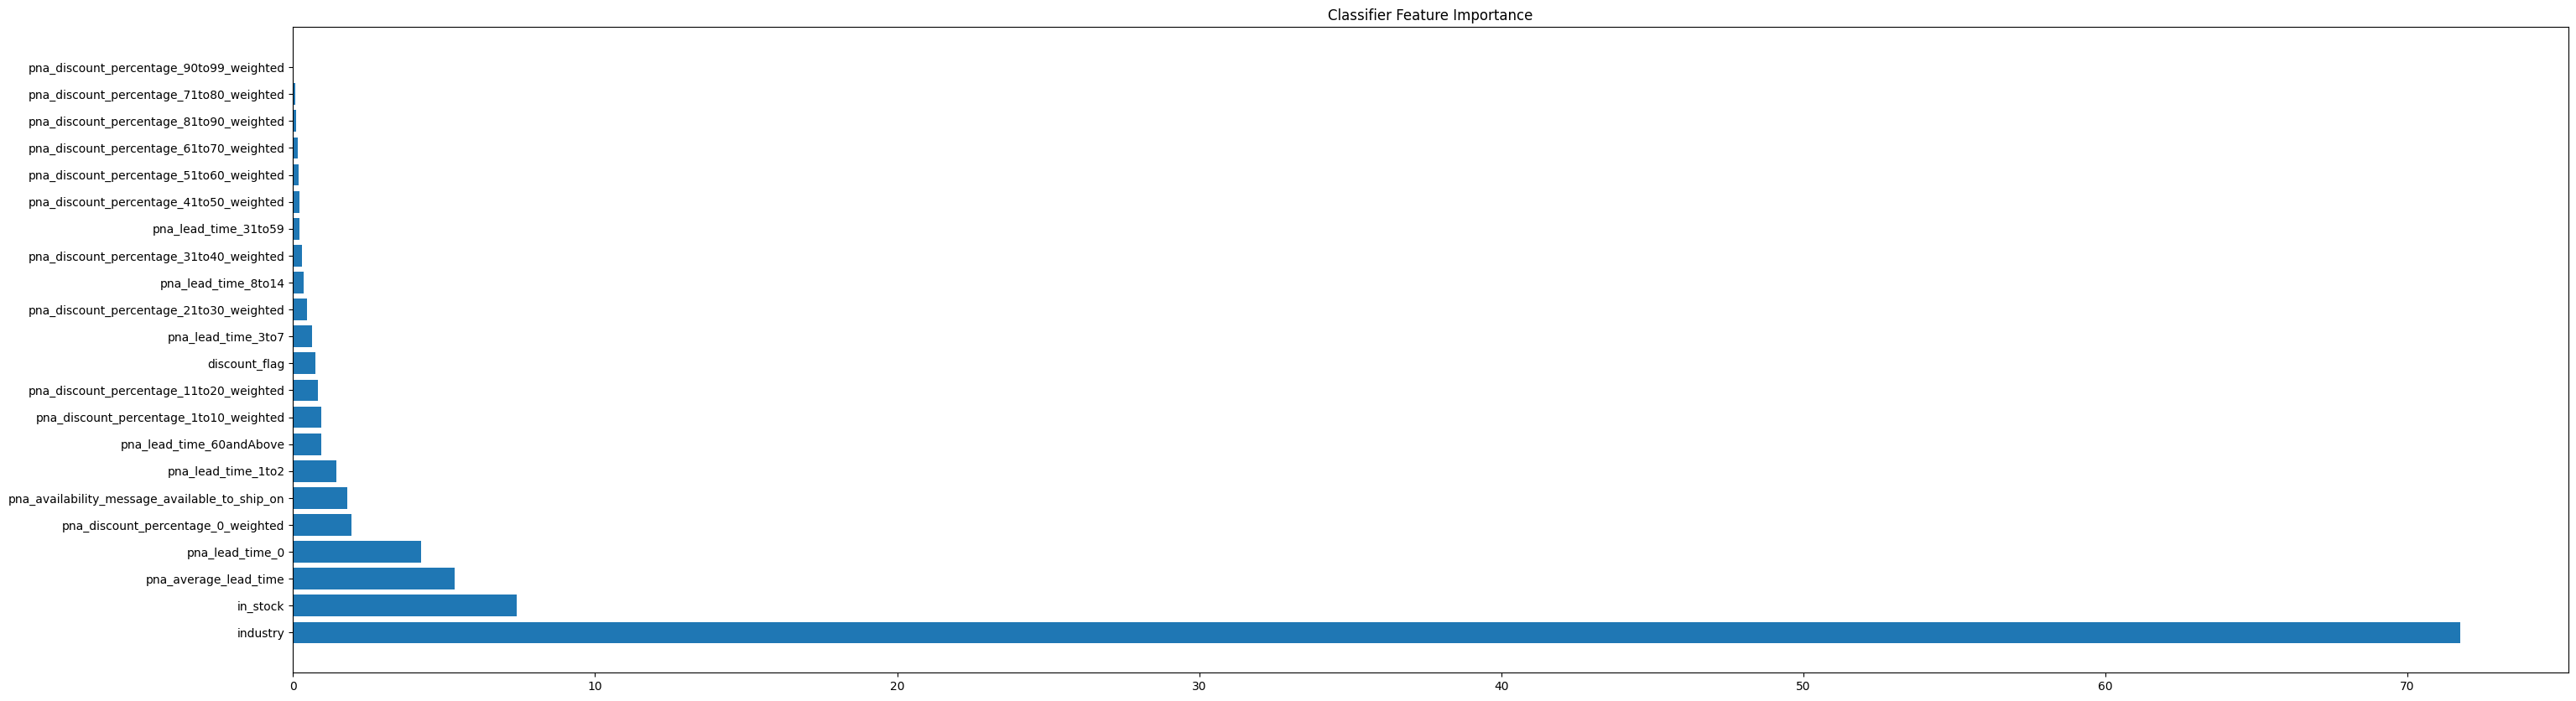

In [ ]:
import matplotlib.pyplot as plt

# classifier importances
fi_clf = clf.get_feature_importance(prettified=True)
#fi_reg = reg.get_feature_importance(prettified=True)

# plot
plt.figure(figsize=(35,10))

plt.barh(fi_clf['Feature Id'], fi_clf['Importances'])
plt.title('Classifier Feature Importance')
#plt.subplot(1,2,2)
#plt.barh(fi_reg['Feature Id'], fi_reg['Importances'])
#plt.title('Regressor Feature Importance')
#plt.tight_layout()
#plt.show()


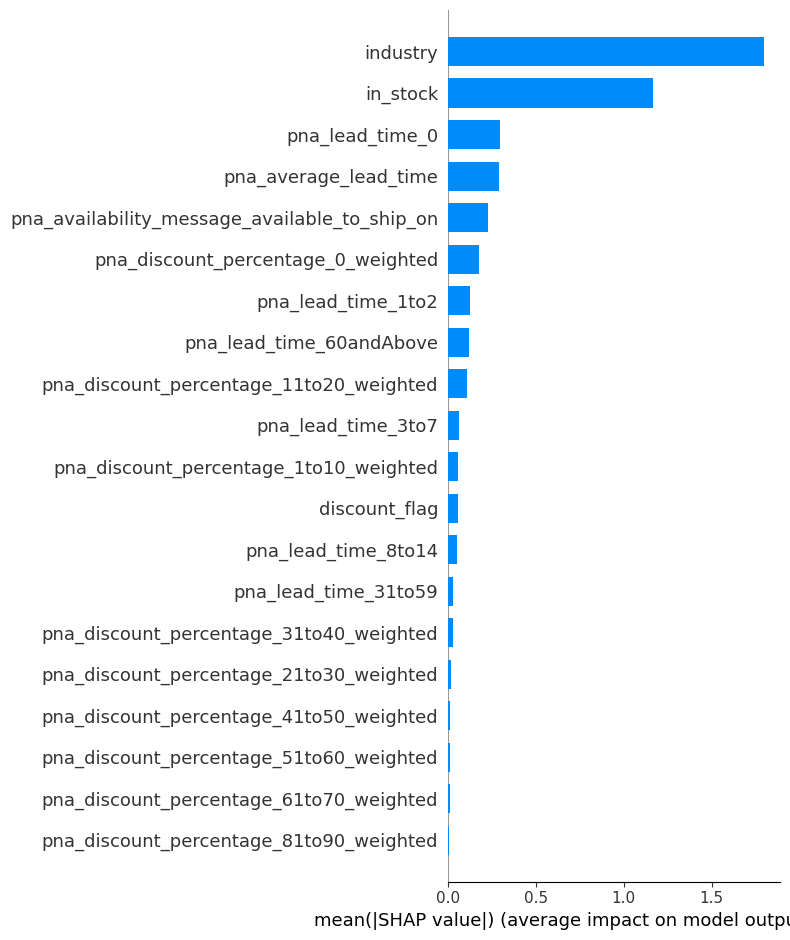

<Figure size 3500x1000 with 0 Axes>

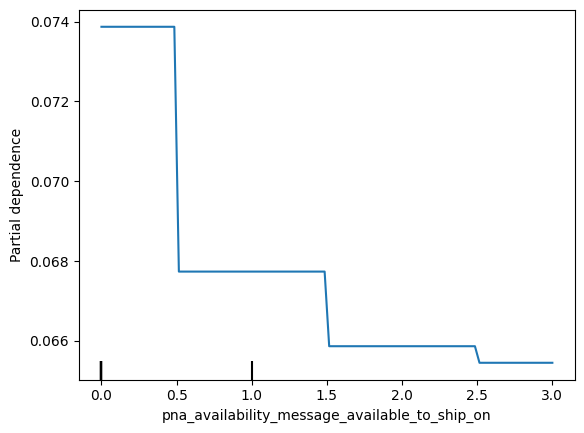

In [ ]:
import shap
#continuous_cols = discount_var + availability_var
#all_cols = cat_cols + continuous_cols + regressor_cols + target_cols
# initialize explainer
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# summary plot for conversion model
shap.summary_plot(shap_values, X_test, plot_type='bar')


from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
plt.figure(figsize=(35,10))
# Replace clf and X_test with your actual model and test data
PartialDependenceDisplay.from_estimator(
    clf,
    X_test,
    #features=continuous_cols
    features=availability_var
    #grid_resolution=20
)

plt.show()

# Example usage
#PartialDependenceDisplay.from_estimator(model, X, features=[0, 1])

#from sklearn.inspection import plot_partial_dependence
#PartialDependenceDisplay(clf, X_test, ['discount_flag','pna_availability_message_in_stock','low_discount','high_discount'], grid_resolution=20)
#plt.show()


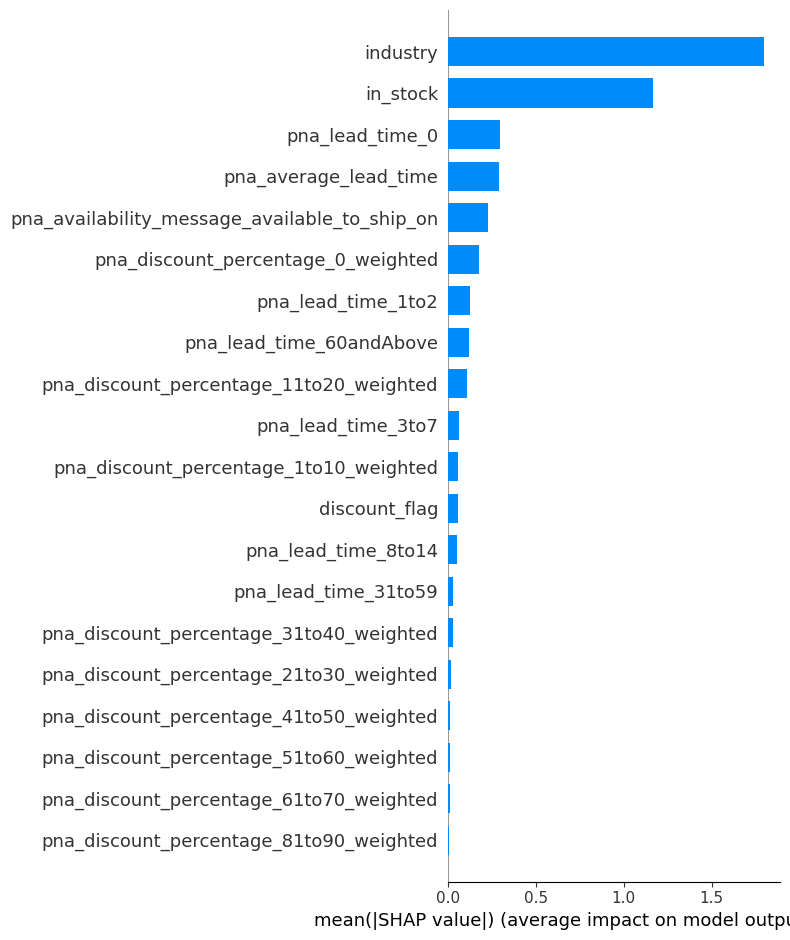

In [ ]:
import shap

# Ensure JS visualizations render in notebooks
shap.initjs()

# Create a TreeExplainer for the trained classifier
explainer_clf = shap.TreeExplainer(clf)

# Compute SHAP values on the test set
shap_values_clf = explainer_clf.shap_values(X_test)



# summary bar plot
shap.summary_plot(
    shap_values_clf, X_test, plot_type="bar",
    feature_names=X_test.columns
)


In [ ]:
print(X_test.columns)

Index(['industry', 'in_stock', 'discount_flag',
       'pna_discount_percentage_0_weighted',
       'pna_discount_percentage_1to10_weighted',
       'pna_discount_percentage_11to20_weighted',
       'pna_discount_percentage_21to30_weighted',
       'pna_discount_percentage_31to40_weighted',
       'pna_discount_percentage_41to50_weighted',
       'pna_discount_percentage_51to60_weighted',
       'pna_discount_percentage_61to70_weighted',
       'pna_discount_percentage_71to80_weighted',
       'pna_discount_percentage_81to90_weighted',
       'pna_discount_percentage_90to99_weighted', 'pna_lead_time_negative',
       'pna_availability_message_available_to_ship_on'],
      dtype='object')


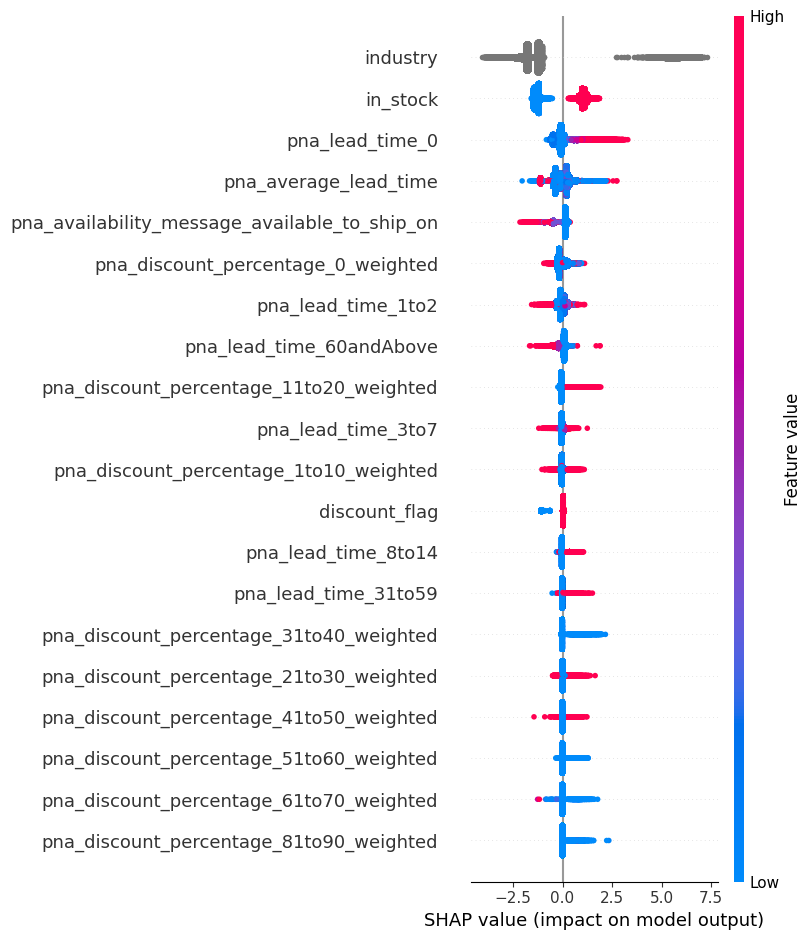

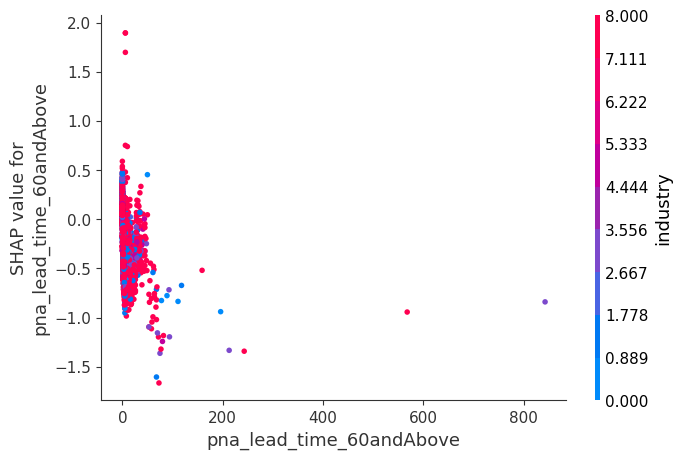

In [ ]:

# beeswarm summary plot
shap.summary_plot(
    shap_values_clf, X_test,
    feature_names=X_test.columns
)


shap.dependence_plot(
    continuous_cols[-1], shap_values_clf, X_test,
    interaction_index="industry",
    feature_names=X_test.columns
)


In [ ]:
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Prevent column width truncation
pd.set_option('display.max_colwidth', None)

# Optional: widen the display in Colab
from IPython.display import display
display(y_test.iloc[326:333])


,bought
351931,1
792227,0
698176,0
1012595,0
119707,0
518260,0
252279,1


In [ ]:
import shap
from IPython.display import display

shap.initjs()  # run once, before the loop

#indices = [326, 127, 88, 402, 510]  # example indices
indices = [320,326,327,330,331,332,333,334]
for idx in indices:
    fp = shap.force_plot(
        explainer_clf.expected_value,
        shap_values_clf[idx],
        X_test.iloc[idx]
    )
    display(fp)  # <-- explicitly display each plot


In [ ]:
#explainer = shap.TreeExplainer(reg)
#shap_values_reg = explainer.shap_values(X_test)
#print(X_test_reg.columns)
#shap.summary_plot(
#    shap_values_reg, X_test_reg, plot_type="bar",
#    feature_names=X_test_reg.columns
#)

#shap.dependence_plot(
#    "pna_availability_message_in_stock", shap_values_reg, X_test_reg,
#    interaction_index="pna_lead_time_31to59",
#    feature_names=X_test_reg.columns
#)


In [ ]:

from sklearn.metrics import accuracy_score

y_pred_clf = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_clf)
print(f"Classification Accuracy: {accuracy:.4f}")


Classification Accuracy: 0.9811


In [ ]:
import pandas as pd
from catboost import CatBoostRegressor, Pool

# Step 2: Separate based on 'bought'
bought_1 = df_set_reduced[df_set_reduced['total_revenue'] > 0.0].copy() # All samples where bought == 1
bought_0 = df_set_reduced[df_set_reduced['total_revenue'] <= 0.0].copy() # All samples where bought == 0
bought_0['industry'] = bought_0['industry'].astype('category')
bought_0['in_stock'] = bought_0['in_stock'].astype('category')
bought_0['discount_flag'] = bought_0['discount_flag'].astype('category')
#df_filtered = df_set_reduced[df_set_reduced['total_revenue'] > 0.0].copy()
#print(len(bought_0))
#print(len(bought_1))

# Downsample 25% of negatives (reproducible with random_state)
#bought_sampled_0 = bought_0.sample(frac=0.25, random_state=42)

print(len(bought_sampled_0))
print(len(bought_1))

262354
64279


In [ ]:

from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


#continuous_cols = discount_var + availability_var
#all_cols = cat_cols + continuous_cols + regressor_cols + target_cols

# 2) Define columns
#cat_cols = ['industry','in_stock','discount_flag']
#continuous_cols = [
#    "pna_lead_time_negative","products_pna_checked",
#    "pna_availability_message_available_to_ship_on",
#    "medium_discount","high_discount","days_diff_session"
#]
#target = "total_revenue"
continuous_cols = discount_var + availability_var
all_cols = cat_cols + continuous_cols + regressor_cols + target_cols

X = bought_1[cat_cols + continuous_cols].copy()
y = np.log1p(bought_1[regressor_cols])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5) Build CatBoost Pools (lets you pass cat_features by *name*)
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_cols)

# 6) Model
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=50
)

# 7) Train
model.fit(train_pool, eval_set=val_pool)

# 8) Evaluate
preds = model.predict(X_val)

# Ensure 1-D vectors with identical shape
y_true = np.asarray(y_val).reshape(-1)   # works for Series or 1-col DataFrame
y_pred = np.asarray(preds).reshape(-1)   # (12856,) even if preds was (12856,1)

# (Optional but recommended) handle zeros to avoid division-by-zero
eps = 1e-8
den = np.clip(np.abs(y_true), eps, None)

rmse = mean_squared_error(y_pred, y_true)#, squared=False)
mae  = mean_absolute_error(y_pred, y_true)
r2   = r2_score(y_val, y_true)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.4f} | R^2: {r2:.4f}")

# 9) Feature importance (top 20)|
importances = model.get_feature_importance(train_pool, type='FeatureImportance')
feat_order = np.argsort(importances)[::-1]
cols = X_train.columns.to_list()
print("Top features:")
for idx in feat_order[:20]:
    print(f"{cols[idx]:<55} {importances[idx]:.3f}")

# 10) Save model (optional)
model.save_model("catboost_regr.cbm")


0:	learn: 1.4746590	test: 1.4890781	best: 1.4890781 (0)	total: 12.4ms	remaining: 6.2s
100:	learn: 1.2482097	test: 1.2637847	best: 1.2637847 (100)	total: 886ms	remaining: 3.5s
200:	learn: 1.2337328	test: 1.2584355	best: 1.2584355 (200)	total: 1.74s	remaining: 2.58s
300:	learn: 1.2267224	test: 1.2571805	best: 1.2571805 (300)	total: 2.59s	remaining: 1.71s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.257118918
bestIteration = 315

Shrink model to first 316 iterations.
RMSE: 1.5803 | MAE: 1.0031 | MAPE: 17.6876 | R^2: 1.0000
Top features:
pna_discount_percentage_0_weighted                      33.201
industry                                                17.133
pna_discount_percentage_1to10_weighted                  13.677
pna_discount_percentage_11to20_weighted                 12.434
pna_availability_message_available_to_ship_on           5.747
pna_discount_percentage_21to30_weighted                 4.359
pna_discount_percentage_31to40_weighted                 3.960

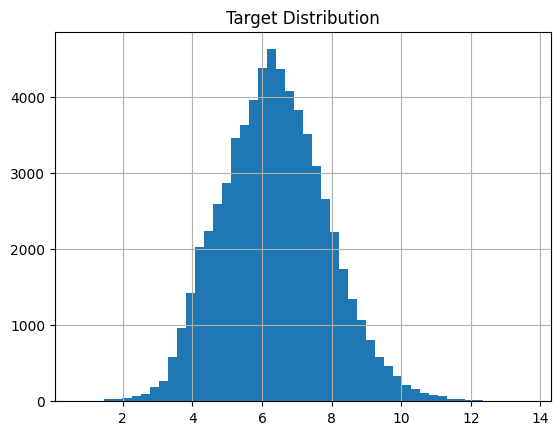

In [ ]:
y = np.log1p(bought_1[regressor_cols])
import matplotlib.pyplot as plt
y.hist(bins=50)
plt.title("Target Distribution")
plt.show()


0:	learn: 1.4873839	test: 1.5017419	best: 1.5017419 (0)	total: 11.9ms	remaining: 9.54s
100:	learn: 1.2537652	test: 1.2672633	best: 1.2672633 (100)	total: 882ms	remaining: 6.11s
200:	learn: 1.2437460	test: 1.2608528	best: 1.2608528 (200)	total: 1.77s	remaining: 5.28s
300:	learn: 1.2362836	test: 1.2580628	best: 1.2580628 (300)	total: 2.61s	remaining: 4.33s
400:	learn: 1.2304878	test: 1.2567065	best: 1.2566976 (398)	total: 3.45s	remaining: 3.43s
500:	learn: 1.2257276	test: 1.2560002	best: 1.2559926 (499)	total: 4.32s	remaining: 2.58s
600:	learn: 1.2224292	test: 1.2558200	best: 1.2557884 (595)	total: 5.2s	remaining: 1.72s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 1.25578839
bestIteration = 595

Shrink model to first 596 iterations.
Original scale → RMSE: 85,713,627.90 | MAE: 2,025.28 | R²: 0.2635 | MAPE: 445.51% | sMAPE: 93.08%


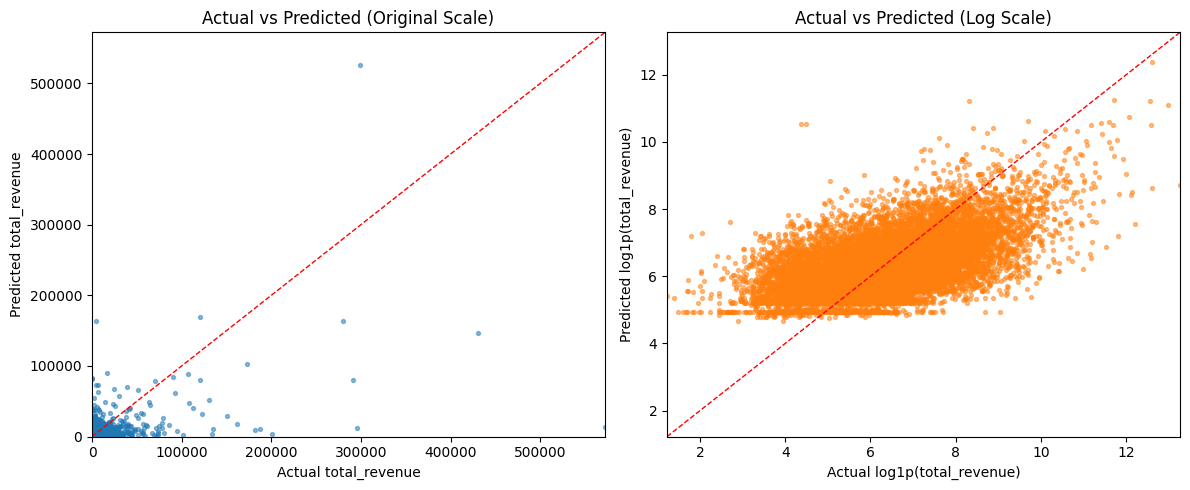

In [ ]:
# 1) Imports
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2) Define columns (your lists)
#cat_cols = ['industry','in_stock','discount_flag']
#continuous_cols = [
#    "pna_lead_time_negative","products_pna_checked",
#    "pna_availability_message_available_to_ship_on",
#    "medium_discount","high_discount","days_diff_session"
#]
target = "total_revenue"

# 3) Build X and y (ensure target is numeric and non-negative for log1p)
X = bought_1[cat_cols + continuous_cols].copy()
y_raw = pd.to_numeric(bought_1[target], errors="coerce").fillna(0.0)

# Optional: if negatives can exist, clip to zero (or choose a different transform strategy)
y_raw = y_raw.clip(lower=0)


# 4) Log-transform the target
y_log = np.log1p(y_raw)

# 5) Split 80/20
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# 6) Pools (pass categorical columns by name)
train_pool = Pool(X_train, y_train_log, cat_features=cat_cols)
val_pool   = Pool(X_val,   y_val_log,   cat_features=cat_cols)

# 7) Model
model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.06,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=80
)

# 8) Train
model.fit(train_pool, eval_set=val_pool)

# 9) Predict (log scale) and back-transform to original scale
preds_val_log = model.predict(X_val)
preds_val = np.expm1(preds_val_log)
y_val = np.expm1(y_val_log)

# --- Optional: Bias correction for log-normal back-transform ---
# If residuals on log scale are ~N(0, sigma^2), E[exp(error)] = exp(0.5*sigma^2).
# This often improves accuracy on the original scale for log-trained models.
apply_bias_correction = True
if apply_bias_correction:
    resid_log = y_val_log - preds_val_log
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)  # unbiased estimate
    correction = np.exp(0.5 * sigma2)
    preds_val_bc = preds_val * correction
else:
    preds_val_bc = preds_val

# 10) Metrics on original scale
rmse = mean_squared_error(y_val, preds_val_bc)
mae  = mean_absolute_error(y_val, preds_val_bc)
r2   = r2_score(y_val, preds_val_bc)

# MAPE: protect against division by zero
with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((y_val - preds_val_bc) / np.where(y_val == 0, np.nan, y_val))) * 100
mape = float(np.nan_to_num(mape, nan=np.inf))  # if many zeros, MAPE can be inf

# SMAPE is often more stable when zeros exist
smape = 100 * np.mean(
    2 * np.abs(preds_val_bc - y_val) / (np.abs(y_val) + np.abs(preds_val_bc) + 1e-12)
)

print(f"Original scale → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# 11) Quick diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Original scale
axes[0].scatter(y_val, preds_val_bc, s=8, alpha=0.5)
lims = [0, max(y_val.max(), preds_val_bc.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title("Actual vs Predicted (Original Scale)")
axes[0].set_xlabel("Actual total_revenue"); axes[0].set_ylabel("Predicted total_revenue")

# (b) Log scale
axes[1].scatter(y_val_log, preds_val_log, s=8, alpha=0.5, color='tab:orange')
lims_log = [min(y_val_log.min(), preds_val_log.min()), max(y_val_log.max(), preds_val_log.max())]
axes[1].plot(lims_log, lims_log, 'r--', linewidth=1)
axes[1].set_xlim(lims_log); axes[1].set_ylim(lims_log)
axes[1].set_title("Actual vs Predicted (Log Scale)")
axes[1].set_xlabel("Actual log1p(total_revenue)"); axes[1].set_ylabel("Predicted log1p(total_revenue)")

plt.tight_layout()
plt.show()

# 12) (Optional) Save model & predictions
# model.save_model("catboost_regr_logtarget.cbm")
# pd.DataFrame({"y_true": y_val, "y_pred": preds_val_bc}).to_csv("val_predictions.csv", index=False)



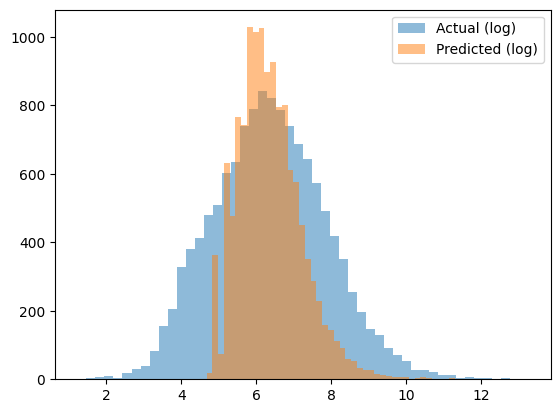

In [ ]:
plt.hist(y_val_log, bins=50, alpha=0.5, label="Actual (log)")
plt.hist(preds_val_log, bins=50, alpha=0.5, label="Predicted (log)")
plt.legend()
plt.show()


In [ ]:
# Imports used in both approaches
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, precision_recall_fscore_support, confusion_matrix
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Your columns
#cat_cols = ['industry','in_stock','discount_flag']
#continuous_cols = [
#    "pna_lead_time_negative","products_pna_checked",
#    "pna_availability_message_available_to_ship_on",
#    "medium_discount","high_discount","days_diff_session"
#]
target = "total_revenue"

# Build X / y (ensure numeric target, handle negatives)
X = bought_1[cat_cols + continuous_cols].copy()
y_raw = pd.to_numeric(bought_1[target], errors="coerce").fillna(0.0)
y_raw = y_raw.clip(lower=0)  # if negatives exist, clip or choose a different transform



0:	learn: 1.3325558	test: 1.3482081	best: 1.3482081 (0)	total: 11.7ms	remaining: 9.35s
100:	learn: 1.1916104	test: 1.2062526	best: 1.2061792 (98)	total: 915ms	remaining: 6.33s
200:	learn: 1.1827825	test: 1.2030868	best: 1.2030868 (200)	total: 1.79s	remaining: 5.33s
300:	learn: 1.1706985	test: 1.1993430	best: 1.1993186 (299)	total: 2.73s	remaining: 4.52s
400:	learn: 1.1629982	test: 1.1979161	best: 1.1978825 (398)	total: 3.63s	remaining: 3.61s
500:	learn: 1.1573185	test: 1.1977482	best: 1.1976386 (445)	total: 4.56s	remaining: 2.72s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 1.197638564
bestIteration = 445

Shrink model to first 446 iterations.
[Weighted Single-Stage] RMSE: 89,634,179.68 | MAE: 1,804.45 | R^2: 0.2298 | MAPE: 175.45% | sMAPE: 84.89%


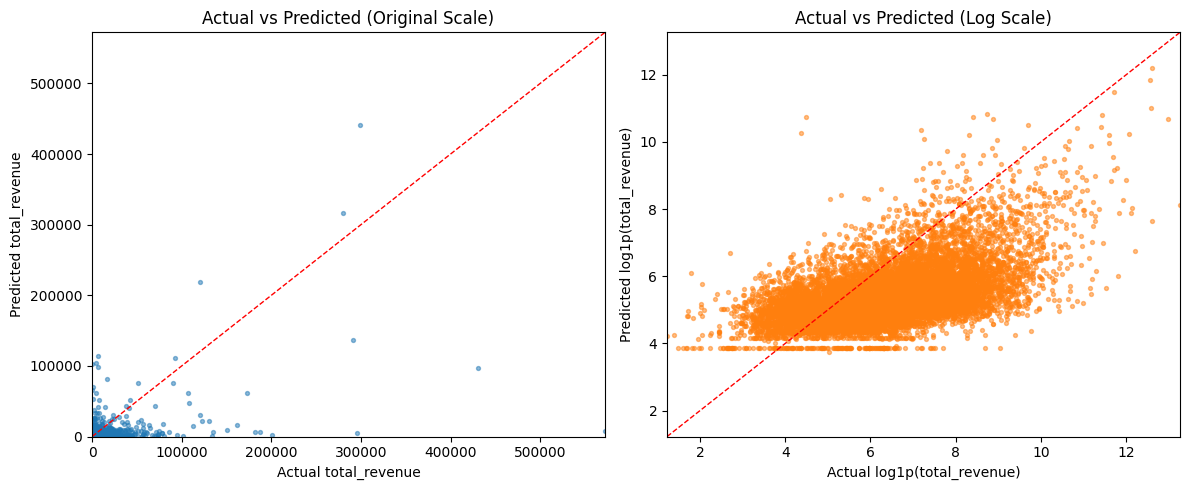

In [ ]:
# ---------- Single-stage weighted regression on log target ----------

# 1) Log-transform target
y_log = np.log1p(y_raw)

# 2) Create sample weights emphasizing low revenues
def make_weights(y, alpha=0.7, w_min=0.2, w_max=5.0, y_floor=1.0):
    """
    Larger weight for small y: w ~ (y_floor + y)^(-alpha).
    Then normalize mean to 1 and clip into [w_min, w_max].
    """
    w = (y_floor + y)**(-alpha)
    w = w / np.mean(w)
    return np.clip(w, w_min, w_max)

weights = make_weights(y_raw, alpha=0.7, w_min=0.2, w_max=5.0, y_floor=1.0)

# 3) Split (80/20)
X_train, X_val, y_train_log, y_val_log, w_train, w_val = train_test_split(
    X, y_log, weights, test_size=0.2, random_state=42
)

# 4) Pools with weights
train_pool = Pool(X_train, y_train_log, cat_features=cat_cols, weight=w_train)
val_pool   = Pool(X_val,   y_val_log,   cat_features=cat_cols, weight=w_val)

# 5) Train model
regr_w = CatBoostRegressor(
    iterations=800,
    learning_rate=0.06,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=80
)
regr_w.fit(train_pool, eval_set=val_pool)

# 6) Predict and back-transform (+ optional bias correction)
preds_val_log = regr_w.predict(X_val)
preds_val = np.expm1(preds_val_log)
y_val = np.expm1(y_val_log)

# Optional global bias correction on original scale
resid_log = y_val_log - preds_val_log
sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)
correction = np.exp(0.5 * sigma2)
preds_val_bc = preds_val * correction

# 7) Evaluate on original scale
rmse = mean_squared_error(y_val, preds_val_bc)
mae  = mean_absolute_error(y_val, preds_val_bc)
r2   = r2_score(y_val, preds_val_bc)

with np.errstate(divide='ignore', invalid='ignore'):
    mape = np.mean(np.abs((y_val - preds_val_bc) / np.where(y_val == 0, np.nan, y_val))) * 100
mape = float(np.nan_to_num(mape, nan=np.inf))

smape = 100 * np.mean(2 * np.abs(preds_val_bc - y_val) / (np.abs(y_val) + np.abs(preds_val_bc) + 1e-12))

print(f"[Weighted Single-Stage] RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")
# 11) Quick diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Original scale
axes[0].scatter(y_val, preds_val_bc, s=8, alpha=0.5)
lims = [0, max(y_val.max(), preds_val_bc.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_title("Actual vs Predicted (Original Scale)")
axes[0].set_xlabel("Actual total_revenue"); axes[0].set_ylabel("Predicted total_revenue")

# (b) Log scale
axes[1].scatter(y_val_log, preds_val_log, s=8, alpha=0.5, color='tab:orange')
lims_log = [min(y_val_log.min(), preds_val_log.min()), max(y_val_log.max(), preds_val_log.max())]
axes[1].plot(lims_log, lims_log, 'r--', linewidth=1)
axes[1].set_xlim(lims_log); axes[1].set_ylim(lims_log)
axes[1].set_title("Actual vs Predicted (Log Scale)")
axes[1].set_xlabel("Actual log1p(total_revenue)"); axes[1].set_ylabel("Predicted log1p(total_revenue)")

plt.tight_layout()
plt.show()

In [ ]:
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# 1) Combine bought_0 and bought_1
bought_0['total_revenue'] = 0.0  # ensure target exists
full_data = pd.concat([bought_0, bought_1], ignore_index=True)


X = full_data[cat_cols + continuous_cols].copy()
y_cls = (full_data[target] > 0).astype(int)  # 1 = positive revenue
y_reg = full_data[target].clip(lower=0)

# 2) Train/val split (stratify by class)
X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)

# 3) Stage 1: Classifier with class weights
pos_ratio = y_train_cls.mean()
class_weights = [1.0, (1.0 - pos_ratio) / (pos_ratio + 1e-12)]  # roughly n_neg/n_pos

clf = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=100,
    early_stopping_rounds=100,
    class_weights=class_weights
)

clf.fit(
    Pool(X_train, y_train_cls, cat_features=cat_cols),
    eval_set=Pool(X_val, y_val_cls, cat_features=cat_cols)
)

p_val = clf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val_cls, p_val)
print(f"[Stage 1: Classifier] AUC: {auc:.4f}")

# 4) Stage 2: Regressor on positives only (log target)
pos_train_mask = (y_train_reg > 0)
X_train_pos = X_train[pos_train_mask]
y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

pos_val_mask = (y_val_reg > 0)
X_val_pos = X_val[pos_val_mask]
y_val_pos_log = np.log1p(y_val_reg[pos_val_mask])

regr = CatBoostRegressor(
    iterations=800,
    learning_rate=0.06,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=42,
    verbose=100,
    early_stopping_rounds=80
)

regr.fit(
    Pool(X_train_pos, y_train_pos_log, cat_features=cat_cols),
    eval_set=Pool(X_val_pos, y_val_pos_log, cat_features=cat_cols)
)

# 5) Combine predictions
p_pos = clf.predict_proba(X_val)[:, 1]
yhat_pos_log = regr.predict(X_val)
yhat_pos = np.expm1(yhat_pos_log)

# Expected revenue = p(positive) * predicted positive revenue
y_pred_expected = p_pos * yhat_pos

# 6) Metrics on original scale
rmse = mean_squared_error(y_val_reg, y_pred_expected)#, squared=False)
mae  = mean_absolute_error(y_val_reg, y_pred_expected)
r2   = r2_score(y_val_reg, y_pred_expected)
print(f"[Two-Stage Expected] RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f}")



0:	test: 0.9827203	best: 0.9827203 (0)	total: 192ms	remaining: 3m 11s
100:	test: 0.9916869	best: 0.9916925 (96)	total: 13.7s	remaining: 2m 1s
200:	test: 0.9917903	best: 0.9917903 (200)	total: 27.4s	remaining: 1m 48s
300:	test: 0.9918777	best: 0.9918877 (298)	total: 40.7s	remaining: 1m 34s
400:	test: 0.9919092	best: 0.9919100 (330)	total: 51.7s	remaining: 1m 17s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.991909997
bestIteration = 330

Shrink model to first 331 iterations.
[Stage 1: Classifier] AUC: 0.9919
0:	learn: 1.4873285	test: 1.5021094	best: 1.5021094 (0)	total: 11.8ms	remaining: 9.39s
100:	learn: 1.2541392	test: 1.2649040	best: 1.2649040 (100)	total: 871ms	remaining: 6.03s
200:	learn: 1.2442378	test: 1.2582349	best: 1.2582349 (200)	total: 1.74s	remaining: 5.17s
300:	learn: 1.2353062	test: 1.2551053	best: 1.2551053 (300)	total: 2.59s	remaining: 4.3s
400:	learn: 1.2297957	test: 1.2539068	best: 1.2539056 (398)	total: 3.45s	remaining: 3.43s
500:	learn: 1.2254

In [ ]:
def sample_df(X, y=None, n=5000, random_state=42):
    """
    Return a random subset of X (and y, if provided) with n rows.
    Keeps alignment between X and y using positional sampling.
    If len(X) <= n, returns X (and y) unchanged.
    """
    import numpy as np
    if len(X) <= n:
        return X, y
    idx = np.random.RandomState(random_state).choice(len(X), size=n, replace=False)
    if y is None:
        return X.iloc[idx], None
    return X.iloc[idx], y.iloc[idx]


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_true = y_val_reg  # original scale, includes zeros

# Baseline A: always predict 0
y_pred_zero = np.zeros_like(y_true)
print("Baseline ZERO →",
      "RMSE:", mean_squared_error(y_true, y_pred_zero),# squared=False),
      "| MAE:", mean_absolute_error(y_true, y_pred_zero),
      "| R^2:", r2_score(y_true, y_pred_zero))

# Baseline B: predict a single constant = mean of training target
const = y_train_reg.mean()
y_pred_mean = np.full_like(y_true, const, dtype=float)
print("Baseline MEAN →",
      "RMSE:", mean_squared_error(y_true, y_pred_mean),#, squared=False),
      "| MAE:", mean_absolute_error(y_true, y_pred_mean),
      "| R^2:", r2_score(y_true, y_pred_mean))


Baseline ZERO → RMSE: 7796723.534155815 | MAE: 128.00266852232883 | R^2: -0.002105908683747826
Baseline MEAN → RMSE: 7780375.078299733 | MAE: 236.87583270292947 | R^2: -4.656261564983666e-06


In [ ]:

# 0) Imports
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, mean_squared_error, mean_absolute_error, r2_score
)
import numpy as np
import pandas as pd

# 1) Config (edit here)
#cat_cols = ['industry','in_stock','discount_flag']
#continuous_cols = [
#    "pna_lead_time_negative","products_pna_checked",
#    "pna_availability_message_available_to_ship_on",
#    "medium_discount","high_discount","days_diff_session"
#]
##target = "total_revenue"

NEG_TO_POS_RATIO = 20     # downsample: keep at most 20x negatives per positive
RANDOM_STATE = 42
USE_BIAS_CORRECTION = True
SEARCH_THRESH_GRID = np.linspace(0.01, 0.80, 40)  # grid for thresholded predictions (RMSE-optimal)

# 2) Build combined dataset
bought_0 = bought_0.copy()
bought_1 = bought_1.copy()

# Ensure the target exists and is numeric
bought_0[target] = 0.0
bought_1[target] = pd.to_numeric(bought_1[target], errors="coerce").fillna(0.0).clip(lower=0)

full = pd.concat([bought_0, bought_1], ignore_index=True)

# Extract X and targets
all_cols = cat_cols + continuous_cols
missing = set(all_cols) - set(full.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

X = full[all_cols].copy()
y_cls = (full[target] > 0).astype(int)                     # Classifier target: 1 = positive revenue
y_reg = pd.to_numeric(full[target], errors="coerce").fillna(0.0).clip(lower=0)  # Regressor target (original scale)


# 4) Downsample negatives BEFORE splitting (keeps stratification meaningful)
def downsample_negatives(X, y_cls, y_reg, neg_to_pos_ratio=20, random_state=42):
    rng = np.random.default_rng(random_state)
    pos_idx = np.where(y_cls == 1)[0]
    neg_idx = np.where(y_cls == 0)[0]
    n_pos = len(pos_idx)
    n_neg_keep = min(len(neg_idx), neg_to_pos_ratio * max(n_pos, 1))
    keep_neg_idx = rng.choice(neg_idx, size=n_neg_keep, replace=False) if n_neg_keep > 0 else np.array([], dtype=int)
    keep_idx = np.concatenate([pos_idx, keep_neg_idx])
    return X.iloc[keep_idx], y_cls.iloc[keep_idx], y_reg.iloc[keep_idx]

X_ds, y_cls_ds, y_reg_ds = downsample_negatives(X, y_cls, y_reg, NEG_TO_POS_RATIO, RANDOM_STATE)

# 5) Train/Val split with stratification on the downsampled set
X_train, X_val, y_train_cls, y_val_cls, y_train_reg, y_val_reg = train_test_split(
    X_ds, y_cls_ds, y_reg_ds, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls_ds
)

# 6) Class weights computed from the ORIGINAL (pre-downsample) imbalance
pos_ratio_full = (y_cls == 1).mean()
class_weights = [1.0, (1.0 - pos_ratio_full) / (pos_ratio_full + 1e-12)]

# 7) Stage 1 — Classifier: p(revenue > 0)
clf = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=120,
    class_weights=class_weights
)

clf.fit(
    Pool(X_train, y_train_cls, cat_features=cat_cols),
    eval_set=Pool(X_val, y_val_cls, cat_features=cat_cols)
)

p_pos = clf.predict_proba(X_val)[:, 1]
try:
    auc = roc_auc_score(y_val_cls, p_pos)
    print(f"[Stage 1: Classifier] AUC: {auc:.4f}")
except Exception as e:
    print("[Stage 1: Classifier] AUC not available:", e)

# 8) Stage 2 — Regressor on positives, with log target
pos_train_mask = (y_train_reg > 0)
X_train_pos = X_train[pos_train_mask]
y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

# Positive subset on validation (for eval & bias correction)
pos_val_mask = (y_val_reg > 0)
X_val_pos = X_val[pos_val_mask]
y_val_pos_log = np.log1p(y_val_reg[pos_val_mask])

regr = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_state=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=150,
    l2_leaf_reg=6.0
)

regr.fit(
    Pool(X_train_pos, y_train_pos_log, cat_features=cat_cols),
    eval_set=Pool(X_val_pos, y_val_pos_log, cat_features=cat_cols)
)

# 9) Predict positive revenue for ALL val rows and back-transform
yhat_pos_log = regr.predict(X_val)
yhat_pos = np.expm1(yhat_pos_log)

# Bias correction computed on positive-only validation residuals (optional but recommended)
if USE_BIAS_CORRECTION and pos_val_mask.any():
    resid_log = y_val_pos_log - regr.predict(X_val_pos)
    sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)
    bc = float(np.exp(0.5 * sigma2))
else:
    bc = 1.0

yhat_pos_bc = yhat_pos * bc

# 10) Combine predictions
# Expected value (smooth, calibrated)
y_pred_expected = p_pos * yhat_pos_bc

# Thresholded (optimize RMSE on validation set)
def evaluate_threshold_grid(y_true, yhat_pos_bc, p_pos, grid):
    best = None
    for t in grid:
        y_pred = np.where(p_pos >= t, yhat_pos_bc, 0.0)
        rmse = mean_squared_error(y_true, y_pred)# squared=False)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        if (best is None) or (rmse < best['rmse']):
            best = {'t': float(t), 'rmse': rmse, 'mae': mae, 'r2': r2}
    return best

best_thresh = evaluate_threshold_grid(y_val_reg.values, yhat_pos_bc, p_pos, SEARCH_THRESH_GRID)
y_pred_thresh = np.where(p_pos >= best_thresh['t'], yhat_pos_bc, 0.0)

# 11) Baselines & metrics
def report_metrics(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred)#, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100
    mape = float(np.nan_to_num(mape, nan=np.inf))
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-12))
    print(f"{name:>24} → RMSE: {rmse:,.2f} | MAE: {mae:,.2f} | R^2: {r2:.4f} | MAPE: {mape:.2f}% | sMAPE: {smape:.2f}%")

# Baselines
y_zero = np.zeros_like(y_val_reg)
y_mean = np.full_like(y_val_reg, fill_value=y_train_reg.mean(), dtype=float)

print("\n=== Baselines ===")
report_metrics("Always Zero", y_val_reg, y_zero)
report_metrics("Global Mean", y_val_reg, y_mean)

print("\n=== Two-Stage Results ===")
report_metrics("Expected Value (p * y+)", y_val_reg, y_pred_expected)
print(f"Best threshold for RMSE: t = {best_thresh['t']:.3f}")
report_metrics("Thresholded (best t)",   y_val_reg, y_pred_thresh)


0:	test: 0.9829462	best: 0.9829462 (0)	total: 173ms	remaining: 3m 27s
100:	test: 0.9918481	best: 0.9918481 (100)	total: 13.5s	remaining: 2m 27s
200:	test: 0.9919777	best: 0.9919777 (199)	total: 26.8s	remaining: 2m 13s
300:	test: 0.9920743	best: 0.9920766 (298)	total: 40.3s	remaining: 2m
400:	test: 0.9920797	best: 0.9920977 (320)	total: 51.4s	remaining: 1m 42s
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.9920976778
bestIteration = 320

Shrink model to first 321 iterations.
[Stage 1: Classifier] AUC: 0.9921
0:	learn: 1.4906455	test: 1.5054979	best: 1.5054979 (0)	total: 14.2ms	remaining: 21.3s
100:	learn: 1.2564407	test: 1.2665785	best: 1.2665785 (100)	total: 875ms	remaining: 12.1s
200:	learn: 1.2487259	test: 1.2607112	best: 1.2607112 (200)	total: 1.71s	remaining: 11s
300:	learn: 1.2399943	test: 1.2560334	best: 1.2560334 (300)	total: 2.55s	remaining: 10.2s
400:	learn: 1.2346871	test: 1.2541929	best: 1.2541929 (400)	total: 3.39s	remaining: 9.28s
500:	learn: 1.230751

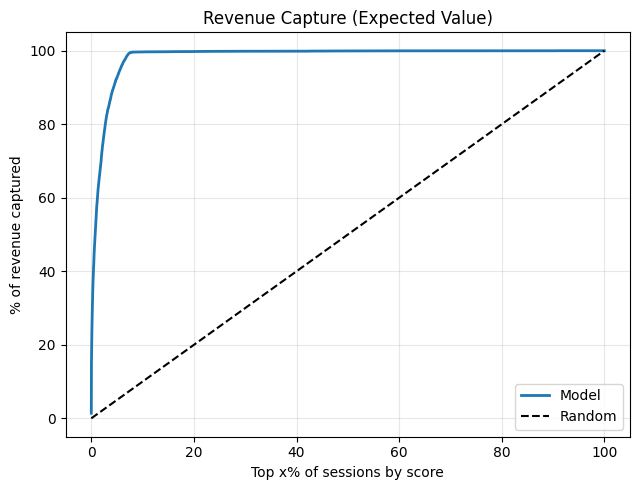


Revenue capture @K% using Expected Value ranking:
Top  1% → capture  56.17% of revenue | lift 56.17×
Top  2% → capture  71.72% of revenue | lift 35.86×
Top  5% → capture  92.70% of revenue | lift 18.54×
Top 10% → capture  99.67% of revenue | lift 9.97×
Top 20% → capture  99.78% of revenue | lift 4.99×
Top 30% → capture  99.86% of revenue | lift 3.33×
Top 50% → capture  99.94% of revenue | lift 2.00×


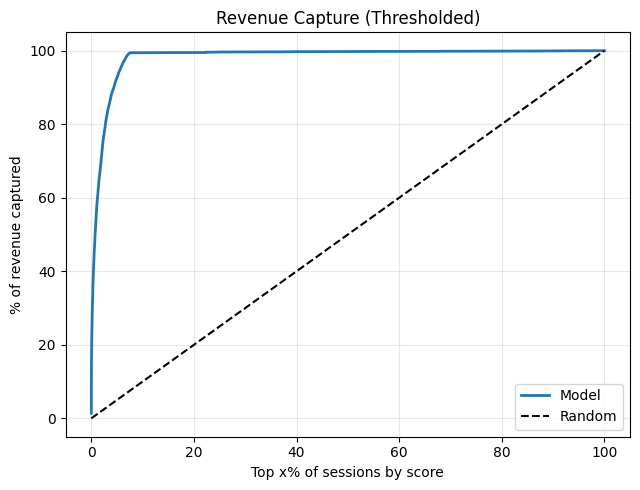


Revenue capture @K% using Thresholded ranking:
Top  1% → capture  56.21% of revenue | lift 56.21×
Top  2% → capture  71.38% of revenue | lift 35.69×
Top  5% → capture  92.67% of revenue | lift 18.53×
Top 10% → capture  99.45% of revenue | lift 9.94×
Top 20% → capture  99.50% of revenue | lift 4.97×
Top 30% → capture  99.67% of revenue | lift 3.32×
Top 50% → capture  99.78% of revenue | lift 2.00×


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def revenue_capture_curve(y_true, score, ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
                          title="Revenue Capture Curve", show_plot=True):
    """
    Computes revenue capture @K% and lift, and (optionally) plots the capture curve.
    - y_true: array-like of actual revenues (original scale)
    - score:  array-like of ranking score (e.g., predicted expected revenue)
    - ks:     tuple/list of top-% cutoffs to report (fractions: 0..1)
    Returns:
      captures: dict[k] -> {'captured_pct': float(0..100), 'lift': float}
      curve_df: DataFrame with 'percentile' (0..1) and 'cum_capture_pct' (0..1)
    """
    df = pd.DataFrame({'y': np.asarray(y_true), 'score': np.asarray(score)}).copy()
    n = len(df)
    if n == 0:
        raise ValueError("Empty inputs to revenue_capture_curve.")
    total_rev = df['y'].sum()
    if total_rev <= 0:
        print("Warning: total revenue in y_true is 0 — capture metrics are not meaningful.")
        total_rev = 1e-12  # avoid divide-by-zero; results will be ~0

    # Sort by score descending (best to worst)
    df = df.sort_values('score', ascending=False).reset_index(drop=True)

    # Cumulative revenue and capture%
    df['cum_revenue'] = df['y'].cumsum()
    df['percentile'] = (np.arange(n) + 1) / n  # 0..1 by rank position
    df['cum_capture_pct'] = df['cum_revenue'] / total_rev  # 0..1

    # Report capture at requested ks
    captures = {}
    for k in ks:
        top = max(1, int(np.ceil(k * n)))
        captured = df.loc[:top-1, 'y'].sum() / total_rev
        lift = (captured / k) if k > 0 else np.nan
        captures[float(k)] = {'captured_pct': captured * 100.0, 'lift': lift}

    # Plot curve
    if show_plot:
        plt.figure(figsize=(6.5, 5))
        plt.plot(df['percentile'] * 100, df['cum_capture_pct'] * 100, label='Model', linewidth=2)
        plt.plot([0, 100], [0, 100], 'k--', label='Random')
        plt.xlabel('Top x% of sessions by score')
        plt.ylabel('% of revenue captured')
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return captures, df[['percentile', 'cum_capture_pct']]

# -----------------------------
# Run revenue capture analysis
# -----------------------------

# Choose the ranking score: expected revenue is typically best for targeting
score_ev = y_pred_expected

# 1) Revenue capture for Expected Value (p × y+)
caps_ev, curve_ev = revenue_capture_curve(
    y_true=y_val_reg,
    score=score_ev,
    ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
    title="Revenue Capture (Expected Value)",
    show_plot=True
)

print("\nRevenue capture @K% using Expected Value ranking:")
for k in [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
    c = caps_ev[k]
    print(f"Top {int(k*100):>2}% → capture {c['captured_pct']:6.2f}% of revenue | lift {c['lift']:.2f}×")

# 2) (Optional) Compare with Thresholded predictions as ranking score
#    Note: Thresholded scores are mostly 0 or positive amounts. Ranking may be coarser than EV.
try:
    caps_th, curve_th = revenue_capture_curve(
        y_true=y_val_reg,
        score=y_pred_thresh,
        ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00),
        title="Revenue Capture (Thresholded)",
        show_plot=True
    )

    print("\nRevenue capture @K% using Thresholded ranking:")
    for k in [0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50]:
        c = caps_th[k]
        print(f"Top {int(k*100):>2}% → capture {c['captured_pct']:6.2f}% of revenue | lift {c['lift']:.2f}×")
except NameError:
    print("\n[Info] y_pred_thresh not found; skipping thresholded capture analysis.")

# 3) (Optional) Save curves to CSV for reporting
# curve_ev.to_csv("revenue_capture_curve_expected.csv", index=False)
# curve_th.to_csv("revenue_capture_curve_thresholded.csv", index=False)


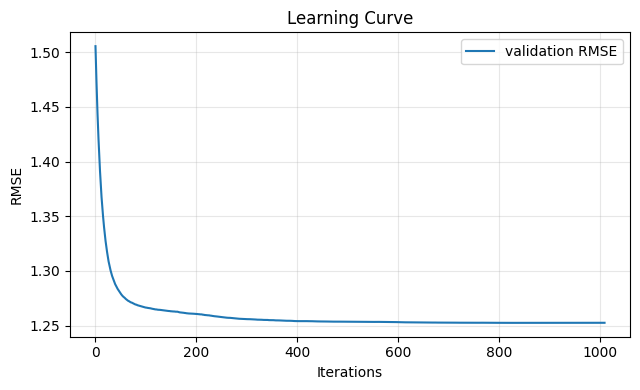

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import shap

def plot_learning_curve(model, metric_name='RMSE'):
    evals = model.get_evals_result()
    if not evals:
        print("No evals history found on model.")
        return
    # Find the first key that looks like a validation set (often 'validation' or 'eval')
    val_key = [k for k in evals.keys() if k.lower().startswith(('valid','eval'))]
    val_key = val_key[0] if val_key else list(evals.keys())[-1]
    if metric_name not in evals[val_key]:
        print(f"Metric {metric_name} not found in evals. Available: {list(evals[val_key].keys())}")
        return
    vals = evals[val_key][metric_name]
    plt.figure(figsize=(6.5,4))
    plt.plot(vals, label=f'{val_key} {metric_name}')
    plt.xlabel('Iterations'); plt.ylabel(metric_name)
    plt.title('Learning Curve'); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    plt.show()

# Example: for your regressor trained on positives (log target)
plot_learning_curve(regr, metric_name='RMSE')



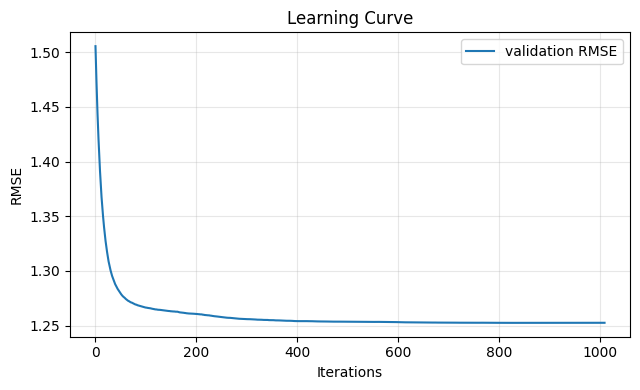

In [ ]:
def plot_learning_curve(model, metric_name='RMSE'):
    evals = model.get_evals_result()
    if not evals:
        print("No evals history found on model.")
        return
    # Find the first key that looks like a validation set (often 'validation' or 'eval')
    val_key = [k for k in evals.keys() if k.lower().startswith(('valid','eval'))]
    val_key = val_key[0] if val_key else list(evals.keys())[-1]
    if metric_name not in evals[val_key]:
        print(f"Metric {metric_name} not found in evals. Available: {list(evals[val_key].keys())}")
        return
    vals = evals[val_key][metric_name]
    plt.figure(figsize=(6.5,4))
    plt.plot(vals, label=f'{val_key} {metric_name}')
    plt.xlabel('Iterations'); plt.ylabel(metric_name)
    plt.title('Learning Curve'); plt.grid(alpha=0.3); plt.legend(); plt.tight_layout()
    plt.show()

# Example: for your regressor trained on positives (log target)
plot_learning_curve(regr, metric_name='RMSE')


<ipython-input-70-2fac72a0891e>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')


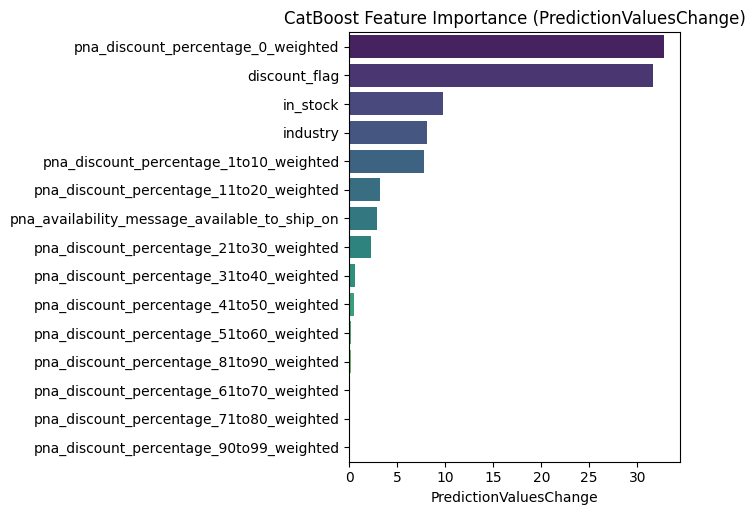

In [ ]:
def plot_catboost_importance(model, X, cat_features, kind='PredictionValuesChange', top_n=20, title=None):
    pool = Pool(X, cat_features=cat_features)
    imps = model.get_feature_importance(pool, type=kind)
    df_imp = pd.DataFrame({'feature': X.columns, 'importance': imps})
    df_imp = df_imp.sort_values('importance', ascending=False).head(top_n)

    plt.figure(figsize=(7, max(4, 0.35*len(df_imp))))
    sns.barplot(x='importance', y='feature', data=df_imp, palette='viridis')
    plt.title(title or f'CatBoost Feature Importance ({kind})')
    plt.xlabel(kind); plt.ylabel('')
    plt.tight_layout(); plt.show()

# On the regressor (positives), using validation features for importance display
plot_catboost_importance(regr, X_val, cat_cols, kind='PredictionValuesChange', top_n=20)
#plot_catboost_importance(regr, X_val, cat_cols, kind='LossFunctionChange', top_n=20)


In [ ]:
print(X_val.columns[2:-2])

Index(['discount_flag', 'pna_discount_percentage_0_weighted',
       'pna_discount_percentage_1to10_weighted',
       'pna_discount_percentage_11to20_weighted',
       'pna_discount_percentage_21to30_weighted',
       'pna_discount_percentage_31to40_weighted',
       'pna_discount_percentage_41to50_weighted',
       'pna_discount_percentage_51to60_weighted',
       'pna_discount_percentage_61to70_weighted',
       'pna_discount_percentage_71to80_weighted',
       'pna_discount_percentage_81to90_weighted',
       'pna_discount_percentage_90to99_weighted'],
      dtype='object')


In [ ]:
print(cat_cols)
print(discount_var)
print(availability_var)
print(regressor_cols)
print(target_cols)

['industry', 'in_stock', 'discount_flag']
['pna_discount_percentage_0_weighted', 'pna_discount_percentage_1to10_weighted', 'pna_discount_percentage_11to20_weighted', 'pna_discount_percentage_21to30_weighted', 'pna_discount_percentage_31to40_weighted', 'pna_discount_percentage_41to50_weighted', 'pna_discount_percentage_51to60_weighted', 'pna_discount_percentage_61to70_weighted', 'pna_discount_percentage_71to80_weighted', 'pna_discount_percentage_81to90_weighted', 'pna_discount_percentage_90to99_weighted']
['pna_availability_message_available_to_ship_on']
['total_revenue']
['purchase']


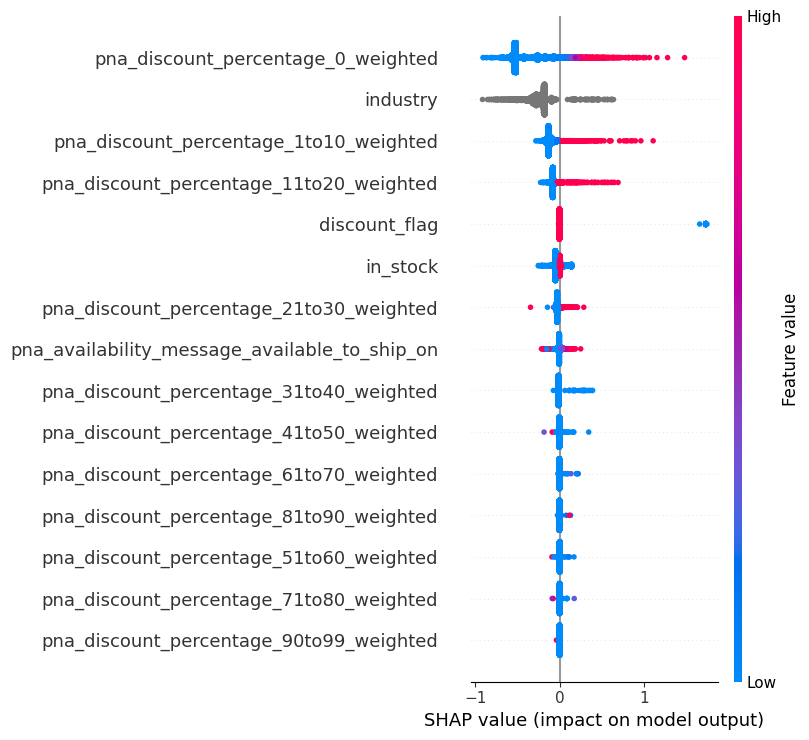

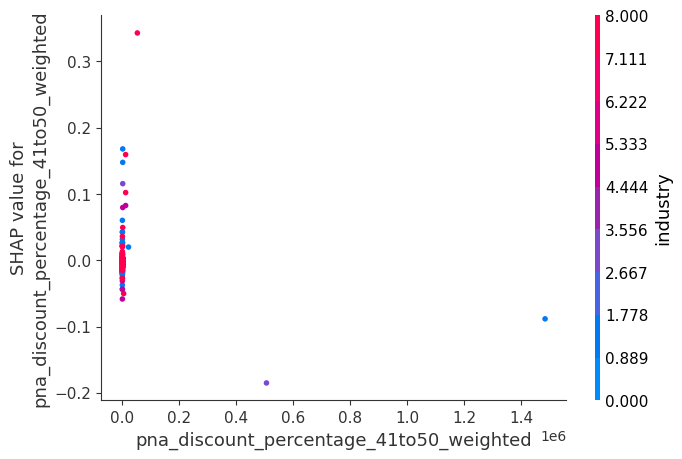

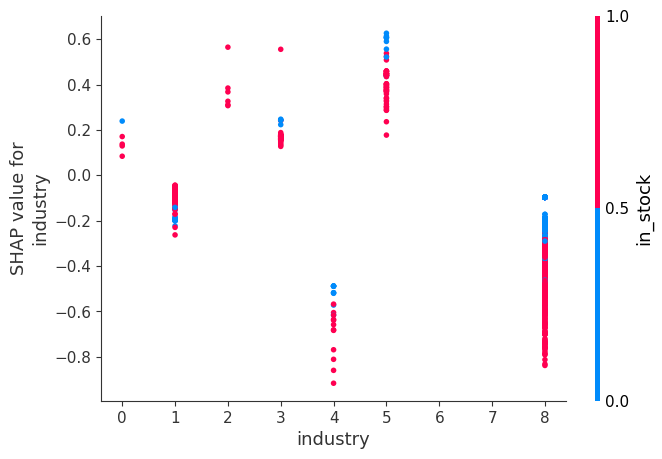

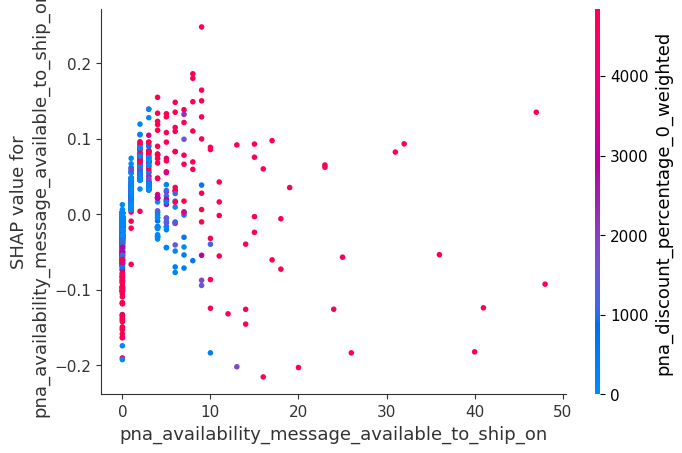

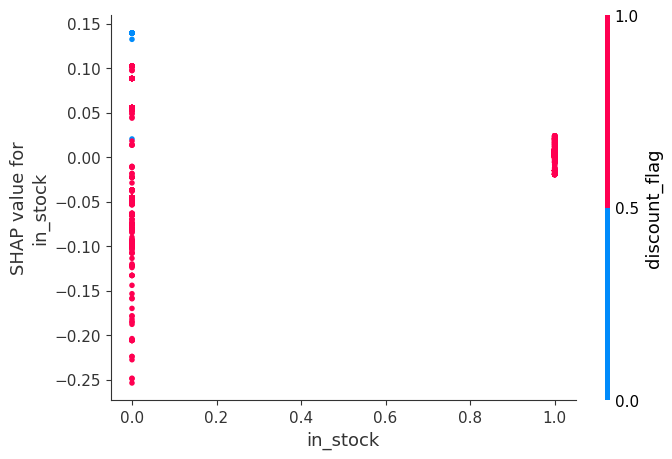

In [ ]:
# Compute SHAP values natively from CatBoost
X_shap, _ = sample_df(X_val, n=4000)  # sample for speed
pool_shap = Pool(X_shap, cat_features=cat_cols)

# get_feature_importance(..., type='ShapValues') returns (n_samples, n_features+1)
shap_vals = regr.get_feature_importance(pool_shap, type='ShapValues')
# Last column is expected value; features are the rest
phi = shap_vals[:, :-1]
expected_value = shap_vals[:, -1]

# Global SHAP summary (beeswarm)
shap.summary_plot(phi, X_shap, feature_names=X_shap.columns, show=True)
#continuous_cols = discount_var + availability_var
#all_cols = cat_cols + continuous_cols + regressor_cols + target_cols
# Per-feature SHAP dependence plot (nonlinear relationships & interactions)
shap.dependence_plot(continuous_cols[5], phi, X_shap, feature_names=X_shap.columns)
# Try on a categorical too (CatBoost handles cats internally)
shap.dependence_plot('industry', phi, X_shap, feature_names=X_shap.columns)

shap.dependence_plot(availability_var[0], phi, X_shap, feature_names=X_shap.columns)
# Try on a categorical too (CatBoost handles cats internally)
shap.dependence_plot('in_stock', phi, X_shap, feature_names=X_shap.columns)


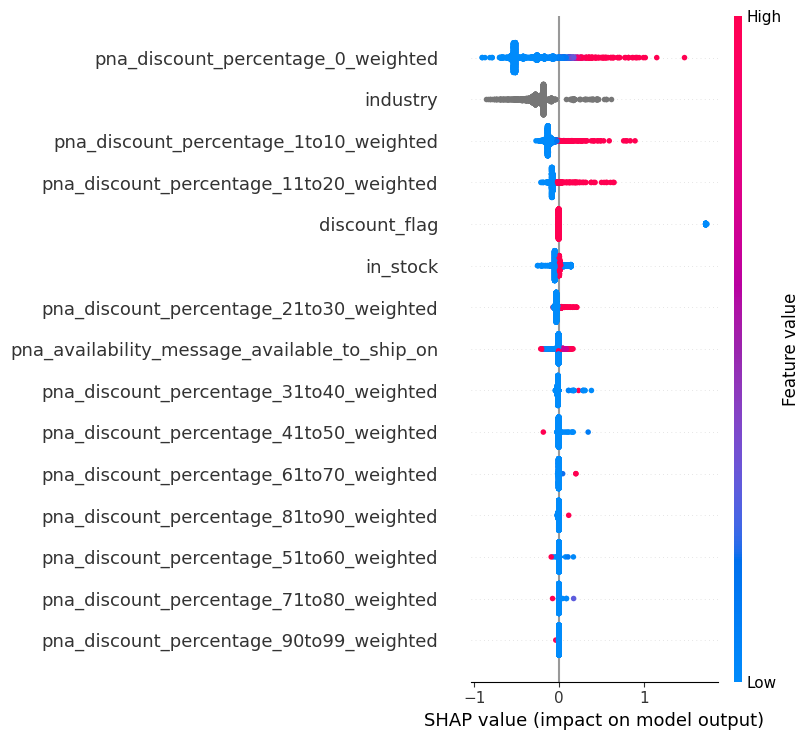

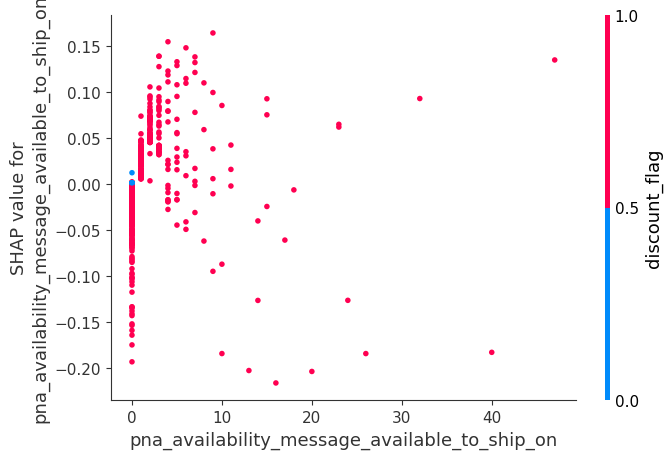

In [ ]:
# Alternative: SHAP TreeExplainer (may be slower but flexible)
X_shap2, _ = sample_df(X_val, n=2000)
explainer = shap.TreeExplainer(regr)
shap_values = explainer.shap_values(X_shap2)

# Beeswarm
shap.summary_plot(shap_values, X_shap2, show=True)

# Dependence plot (with interaction highlight)
shap.dependence_plot('pna_availability_message_available_to_ship_on', shap_values, X_shap2, interaction_index='discount_flag')


207101


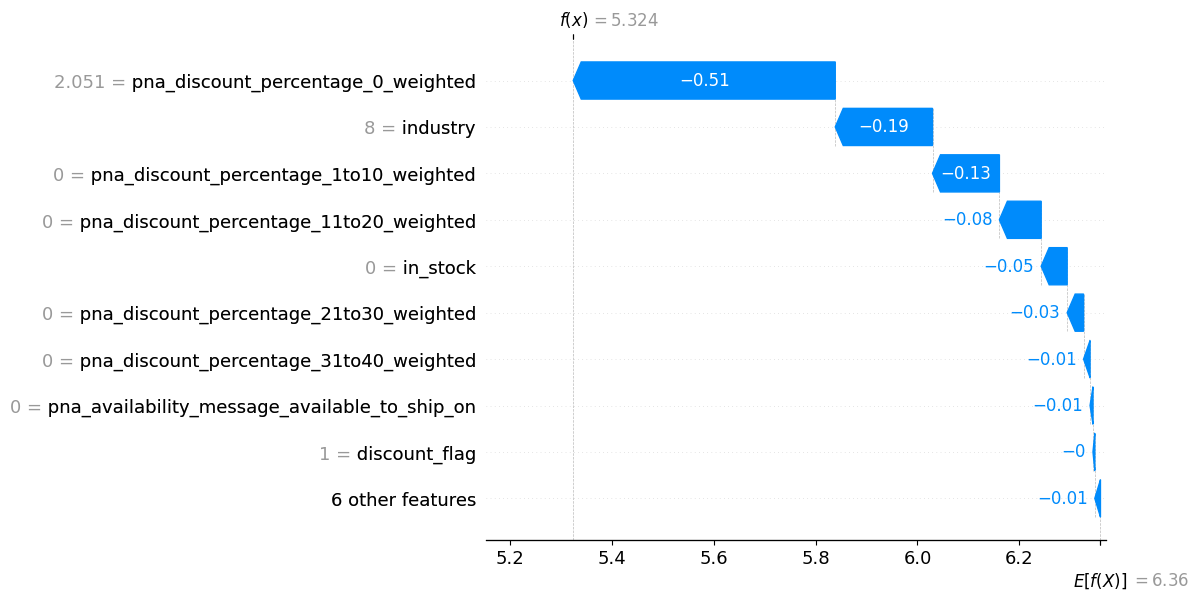

In [ ]:
i = int(np.argmax(regr.predict(X_val)))  # index within X_val
row = X_val.iloc[[100]]
print(i)
exp = shap.TreeExplainer(regr)
sv = exp.shap_values(row)
shap.waterfall_plot(shap.Explanation(values=sv[0], base_values=exp.expected_value, data=row.values[0], feature_names=row.columns))


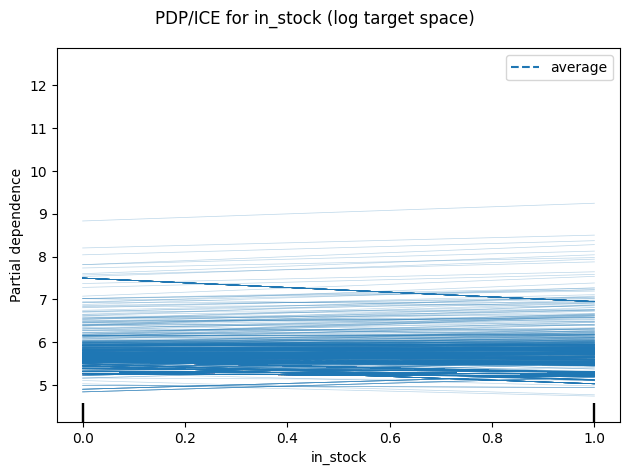

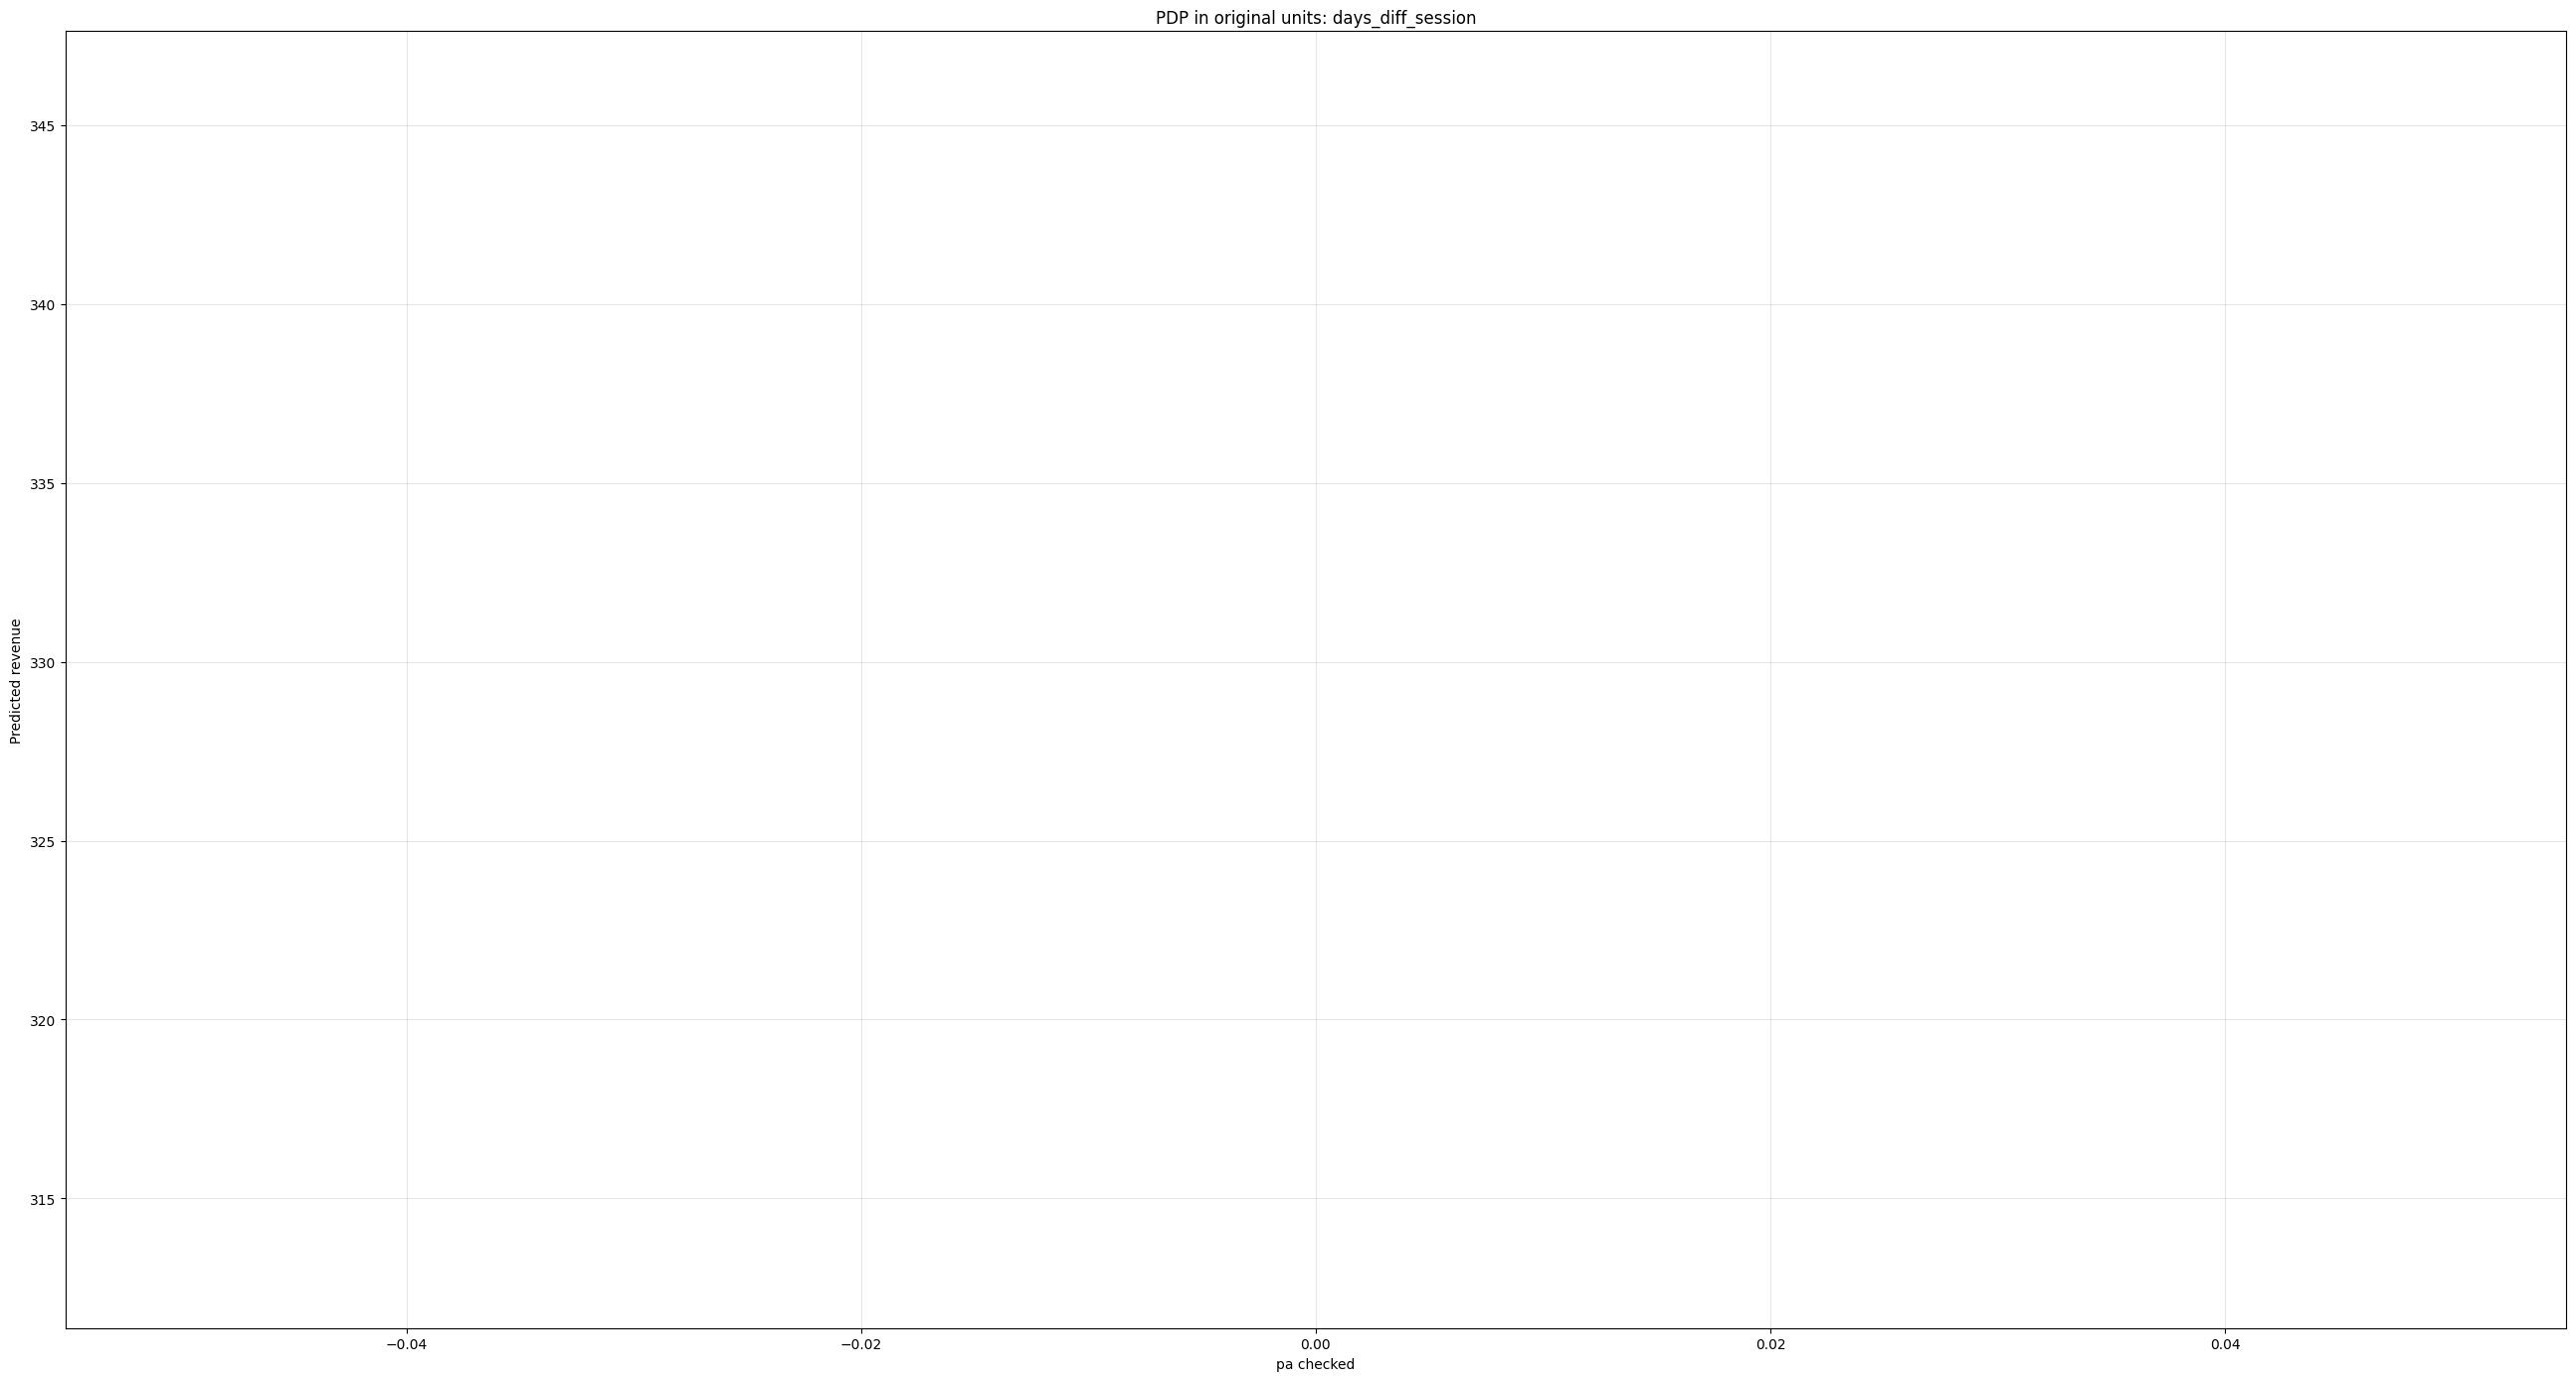

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# For tree models, this works directly; model.predict is used under the hood.
# IMPORTANT: PDP will be in the model’s output scale (log space for your regressor).
feat = 'in_stock'
PartialDependenceDisplay.from_estimator(
    regr, X_val, [feat], kind='both', grid_resolution=25, subsample=2000,
)
plt.suptitle(f'PDP/ICE for {feat} (log target space)'); plt.tight_layout(); plt.show()

# If you want PDP in ORIGINAL revenue units, do a manual loop with back-transform:
def pdp_original_units(model, X, feature, grid=None, n=100):
    Xc = X.copy()
    if grid is None:
        grid = np.linspace(Xc[feature].quantile(0.01), Xc[feature].quantile(0.99), n)
    preds = []
    for v in grid:
        Xc[feature] = v
        yhat_log = model.predict(Xc)
        preds.append(np.expm1(yhat_log))  # back-transform
    return grid, np.mean(preds, axis=1)

grid, pdp_mean = pdp_original_units(regr, X_val.copy(), 'pna_discount_percentage_31to40_weighted')
plt.figure(figsize=(26,14))
plt.plot(grid, pdp_mean)
plt.title('PDP in original units: days_diff_session'); plt.xlabel('pa checked'); plt.ylabel('Predicted revenue')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


<ipython-input-78-fa0b7ac7dd07>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_imp = tmp.groupby(cat)['abs_shap'].mean().sort_values(ascending=False).head(25)
<ipython-input-78-fa0b7ac7dd07>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_imp.values, y=cat_imp.index, palette='magma')


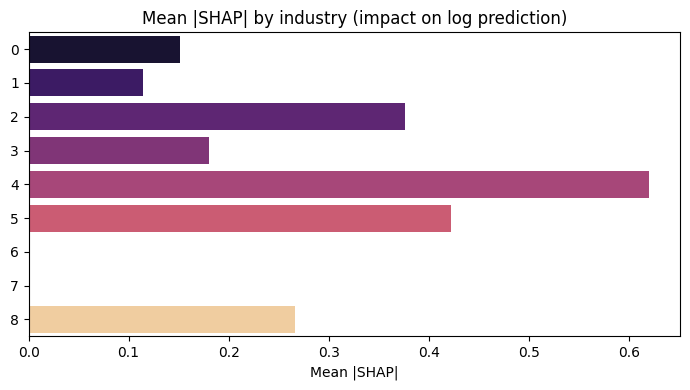

In [ ]:
# Using native SHAP phi from §3a
phi_df = pd.DataFrame(phi, columns=X_shap.columns)
Xsh = X_shap.reset_index(drop=True)
phi_df['row_sum'] = phi_df.abs().sum(axis=1)  # sanity check

cat = 'industry'  # choose a categorical
tmp = pd.concat([Xsh[[cat]], phi_df[cat].abs().rename('abs_shap')], axis=1).dropna()
cat_imp = tmp.groupby(cat)['abs_shap'].mean().sort_values(ascending=False).head(25)

plt.figure(figsize=(7, max(4, 0.35*len(cat_imp))))
sns.barplot(x=cat_imp.values, y=cat_imp.index, palette='magma')
plt.title(f"Mean |SHAP| by {cat} (impact on log prediction)"); plt.xlabel('Mean |SHAP|'); plt.ylabel('')
plt.tight_layout(); plt.show()


<ipython-input-79-4ce32f747bd6>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_cat = pd.DataFrame({'cat': full.loc[X_val.index, 'industry'].values, 'yhat': yhat_all}).groupby('cat')['yhat'].mean().sort_values(ascending=False).head(25)
<ipython-input-79-4ce32f747bd6>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=by_cat.values, y=by_cat.index, palette='Blues_r')


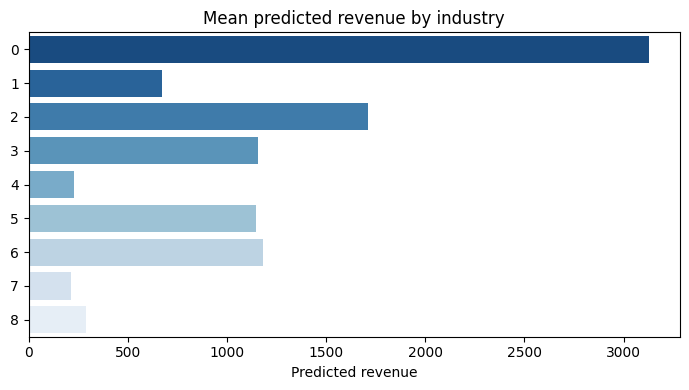

In [ ]:
# Average predicted revenue (original units) by category
yhat_log_all = regr.predict(X_val)
yhat_all = np.expm1(yhat_log_all)
by_cat = pd.DataFrame({'cat': full.loc[X_val.index, 'industry'].values, 'yhat': yhat_all}).groupby('cat')['yhat'].mean().sort_values(ascending=False).head(25)

plt.figure(figsize=(7, max(4, 0.35*len(by_cat))))
sns.barplot(x=by_cat.values, y=by_cat.index, palette='Blues_r')
plt.title('Mean predicted revenue by industry'); plt.xlabel('Predicted revenue'); plt.ylabel('')
plt.tight_layout(); plt.show()


In [ ]:
def generate_two_stage_html_report(
    clf, regr,
    X_train, X_val,
    y_train_reg, y_val_reg,
    cat_cols,
    report_path="two_stage_model_report.html",
    title="Two-Stage Revenue Model — HTML Report",
    segment_series=None,            # optional pd.Series aligned to X_val.index (e.g., customer_segment)
    include_thresholded=True,
    threshold_grid=None,            # e.g., np.linspace(0.01, 0.80, 40); default set inside
    use_bias_correction=True,
    shap_sample_n=4000,
    pdp_features=None,              # list of feature names to PDP; default auto-selects
    random_state=42
):
    """
    Creates a self-contained HTML report with:
      - Classifier & Regressor learning curves
      - CatBoost feature importance (two types)  <-- FIXED: labeled Pool
      - SHAP (summary + dependence)
      - PDP/ICE including back-transform to original revenue units
      - Residual diagnostics
      - Feature interactions  <-- FIXED: labeled Pool
      - Metrics (RMSE/MAE/R², wMAPE, sMAPE)
      - Revenue capture (EV + Thresholded)
      - Optional: capture by segment
    """
    import io, base64, warnings
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import (
        roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
        mean_squared_error, mean_absolute_error, r2_score
    )
    from catboost import Pool

    # Optional: SHAP
    try:
        import shap
        HAS_SHAP = True
    except Exception:
        HAS_SHAP = False
        warnings.warn("SHAP not available; SHAP sections will be skipped.")

    sns.set(style="whitegrid")

    # ------------------------
    # Helpers
    # ------------------------
    def fig_to_base64(fig):
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
        buf.seek(0)
        b64 = base64.b64encode(buf.read()).decode('utf-8')
        plt.close(fig)
        return f'<img src="data:image/png;base64,{b64}" style="max-width:100%; height:auto;" />'

    def metrics_block(y_true, y_pred, name):
        rmse = mean_squared_error(y_true, y_pred)#, squared=False)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        denom = np.sum(np.abs(y_true))
        wmape = np.nan if denom == 0 else 100.0 * np.sum(np.abs(y_true - y_pred)) / denom
        smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-12))
        html = f"""
        <table class="table-metrics">
          <tr><th colspan="2">{name}</th></tr>
          <tr><td>RMSE</td><td>{rmse:,.2f}</td></tr>
          <tr><td>MAE</td><td>{mae:,.2f}</td></tr>
          <tr><td>R²</td><td>{r2:.4f}</td></tr>
          <tr><td>wMAPE</td><td>{wmape:.2f}%</td></tr>
          <tr><td>sMAPE</td><td>{smape:.2f}%</td></tr>
        </table>
        """
        return html, (rmse, mae, r2, wmape, smape)

    def revenue_capture(y_true, score, ks=(0.01, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00), title="Revenue Capture"):
        df = pd.DataFrame({'y': np.asarray(y_true), 'score': np.asarray(score)}).copy()
        n = len(df)
        total_rev = df['y'].sum()
        df = df.sort_values('score', ascending=False).reset_index(drop=True)
        df['cum_revenue'] = df['y'].cumsum()
        df['percentile'] = (np.arange(n) + 1) / n
        df['cum_capture_pct'] = df['cum_revenue'] / (total_rev + 1e-12)

        fig, ax = plt.subplots(figsize=(6.5,5))
        ax.plot(df['percentile']*100, df['cum_capture_pct']*100, label='Model', linewidth=2)
        ax.plot([0,100],[0,100],'k--',label='Random')
        ax.set_xlabel('Top x% of sessions by score'); ax.set_ylabel('% of revenue captured')
        ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
        img_html = fig_to_base64(fig)

        rows = []
        for k in ks:
            top = max(1, int(np.ceil(k * n)))
            captured = df.loc[:top-1, 'y'].sum() / (total_rev + 1e-12)
            lift = captured / k if k > 0 else np.nan
            rows.append((k, captured*100.0, lift))

        tbl = ['<table class="table-capture"><tr><th>Top %</th><th>Capture %</th><th>Lift</th></tr>']
        for k, cap, lift in rows:
            tbl.append(f"<tr><td>{int(k*100)}%</td><td>{cap:,.2f}%</td><td>{lift:.2f}×</td></tr>")
        tbl.append("</table>")
        tbl_html = "\n".join(tbl)
        return img_html, tbl_html

    def plot_learning_curve(model, title="Learning Curve", metric='RMSE'):
        evals = model.get_evals_result()
        if not evals:
            return "<p><em>No eval history available for this model.</em></p>"
        pref = [k for k in evals if k.lower().startswith(('valid', 'eval'))]
        key = pref[0] if pref else list(evals.keys())[-1]
        if metric not in evals[key]:
            return f"<p><em>Metric '{metric}' not found in evals results.</em></p>"
        vals = evals[key][metric]
        fig, ax = plt.subplots(figsize=(6.5,4))
        ax.plot(vals, label=f"{key} {metric}")
        ax.set_xlabel("Iterations"); ax.set_ylabel(metric)
        ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
        return fig_to_base64(fig)

    # NOTE: patched to accept y (labels) and silence the Seaborn palette warning
    def get_catboost_importance(model, X, y, cat_features, type_name='PredictionValuesChange', top_n=20, title=None):
        """
        For regression importance types like 'LossFunctionChange', a labeled Pool is required.
        We pass y so both types are safe.
        """
        pool = Pool(X, label=y, cat_features=cat_features)
        imps = model.get_feature_importance(pool, type=type_name)
        df_imp = pd.DataFrame({'feature': X.columns, 'importance': imps}).sort_values('importance', ascending=False).head(top_n)
        fig, ax = plt.subplots(figsize=(7, max(4, 0.35*len(df_imp))))
        # Seaborn 0.14+: provide hue to use palette without deprecation warning
        sns.barplot(x='importance', y='feature', data=df_imp, hue='feature', palette='viridis',
                    dodge=False, legend=False, ax=ax)
        ax.set_title(title or f"CatBoost Feature Importance — {type_name}")
        ax.set_xlabel(type_name); ax.set_ylabel("")
        return fig_to_base64(fig), df_imp

    # ------------------------
    # Build positive training subset for labeled Pools (importance/interaction)
    # ------------------------
    pos_train_mask = (y_train_reg > 0)
    X_train_pos = X_train[pos_train_mask]
    y_train_pos_log = np.log1p(y_train_reg[pos_train_mask])

    # ------------------------
    # Predictions (Val)
    # ------------------------
    y_val_cls = (y_val_reg > 0).astype(int)
    p_pos = clf.predict_proba(X_val)[:, 1]
    auc_html = ""
    try:
        auc = roc_auc_score(y_val_cls, p_pos)
        fpr, tpr, _ = roc_curve(y_val_cls, p_pos)
        prec, rec, _ = precision_recall_curve(y_val_cls, p_pos)
        ap = average_precision_score(y_val_cls, p_pos)

        fig, ax = plt.subplots(1,2, figsize=(11,4))
        ax[0].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        ax[0].plot([0,1],[0,1],'k--'); ax[0].set_title("ROC Curve"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend(); ax[0].grid(alpha=0.3)
        ax[1].plot(rec, prec, label=f"AP = {ap:.3f}")
        ax[1].set_title("Precision-Recall Curve"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend(); ax[1].grid(alpha=0.3)
        auc_html = fig_to_base64(fig)
    except Exception as e:
        auc_html = f"<p><em>Could not compute ROC/PR curves: {e}</em></p>"

    # Regressor: predict log, back-transform, optional bias correction on positives
    yhat_pos_log = regr.predict(X_val)
    yhat_pos = np.expm1(yhat_pos_log)

    bc = 1.0
    pos_mask = (y_val_reg > 0)
    if use_bias_correction and pos_mask.any():
        y_val_pos_log = np.log1p(y_val_reg[pos_mask])
        resid_log = y_val_pos_log - regr.predict(X_val[pos_mask])
        sigma2 = np.var(resid_log[~np.isnan(resid_log)], ddof=1)
        bc = float(np.exp(0.5 * sigma2))
    yhat_pos_bc = yhat_pos * bc

    # Expected value & Thresholded
    y_pred_expected = p_pos * yhat_pos_bc
    if threshold_grid is None:
        threshold_grid = np.linspace(0.01, 0.80, 40)

    best = None
    if include_thresholded:
        for t in threshold_grid:
            y_pred = np.where(p_pos >= t, yhat_pos_bc, 0.0)
            rmse = mean_squared_error(y_val_reg, y_pred)#, squared=False)
            if (best is None) or (rmse < best['rmse']):
                mae  = mean_absolute_error(y_val_reg, y_pred)
                r2   = r2_score(y_val_reg, y_pred)
                best = {'t': float(t), 'rmse': rmse, 'mae': mae, 'r2': r2}
        y_pred_thresh = np.where(p_pos >= best['t'], yhat_pos_bc, 0.0)
    else:
        y_pred_thresh = None

    # ------------------------
    # Metrics & baselines
    # ------------------------
    y_zero = np.zeros_like(y_val_reg)
    y_mean = np.full_like(y_val_reg, fill_value=float(np.mean(y_train_reg)), dtype=float)

    html_baselines = []
    html_ev, _ = metrics_block(y_val_reg, y_pred_expected, "Expected Value (p × y⁺)")
    html_baselines.append(metrics_block(y_val_reg, y_zero, "Baseline — Always Zero")[0])
    html_baselines.append(metrics_block(y_val_reg, y_mean, "Baseline — Global Mean")[0])
    html_thresh = metrics_block(y_val_reg, y_pred_thresh, f"Thresholded (best t={best['t']:.3f})")[0] if y_pred_thresh is not None else ""

    # Residual diagnostics (Original scale; use EV by default)
    y_pred_for_plots = y_pred_expected
    resid = y_val_reg - y_pred_for_plots
    fig, axes = plt.subplots(1,3, figsize=(15,4))
    axes[0].scatter(y_val_reg, y_pred_for_plots, s=8, alpha=0.5)
    lim = [0, max(np.max(y_val_reg), np.max(y_pred_for_plots)) if len(y_val_reg)>0 else 1]
    axes[0].plot(lim, lim, 'r--'); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
    axes[0].set_title("Actual vs Predicted (EV)"); axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
    axes[1].scatter(y_pred_for_plots, resid, s=8, alpha=0.5)
    axes[1].axhline(0, color='r', linestyle='--'); axes[1].set_title("Residuals vs Predicted")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
    sns.histplot(resid, bins=50, kde=True, ax=axes[2])
    axes[2].set_title("Residual Distribution (EV)")
    resid_html = fig_to_base64(fig)

    # ------------------------
    # Feature importance (CatBoost)  <-- FIXED: labeled Pool from positive train subset
    # ------------------------
    imp_pred_html, df_imp_pred = get_catboost_importance(
        regr, X_train_pos, y_train_pos_log, cat_cols,
        type_name='PredictionValuesChange',
        top_n=20, title="Regressor Feature Importance — PredictionValuesChange"
    )
    imp_loss_html, df_imp_loss = get_catboost_importance(
        regr, X_train_pos, y_train_pos_log, cat_cols,
        type_name='LossFunctionChange',
        top_n=20, title="Regressor Feature Importance — LossFunctionChange"
    )

    # ------------------------
    # Learning curves
    # ------------------------
    lc_regr = plot_learning_curve(regr, title="Regressor Learning Curve (RMSE)", metric='RMSE')
    lc_clf  = plot_learning_curve(clf,  title="Classifier Learning Curve (AUC)", metric='AUC')

    # ------------------------
    # SHAP (Regressor on log target)
    # ------------------------
    shap_html_blocks = []
    if HAS_SHAP:
        try:
            if len(X_val) > shap_sample_n:
                idx = X_val.sample(n=shap_sample_n, random_state=random_state).index
                X_shap = X_val.loc[idx]
            else:
                X_shap = X_val

            pool_shap = Pool(X_shap, cat_features=cat_cols)
            shap_vals = regr.get_feature_importance(pool_shap, type='ShapValues')
            phi = shap_vals[:, :-1]
            plt.figure()
            shap.summary_plot(phi, X_shap, feature_names=X_shap.columns, show=False)
            fig = plt.gcf()
            shap_summary_html = fig_to_base64(fig)

            mean_abs = np.mean(np.abs(phi), axis=0)
            top_features = list(np.array(X_shap.columns)[np.argsort(-mean_abs)[:3]])

            dep_plots_html = []
            for feat in top_features:
                plt.figure()
                shap.dependence_plot(feat, phi, X_shap, feature_names=X_shap.columns, show=False)
                fig = plt.gcf()
                dep_plots_html.append(fig_to_base64(fig))

            shap_html_blocks.append(f"<h3>SHAP Summary (Regressor, log target space)</h3>{shap_summary_html}")
            for i, feat in enumerate(top_features, 1):
                shap_html_blocks.append(f"<h4>SHAP Dependence: {feat}</h4>{dep_plots_html[i-1]}")

        except Exception as e:
            shap_html_blocks.append(f"<p><em>SHAP computation failed: {e}</em></p>")
    else:
        shap_html_blocks.append("<p><em>SHAP not installed — skipping SHAP visuals.</em></p>")

    # ------------------------
    # PDP (original units)
    # ------------------------
    if pdp_features is None:
        cont_in_X = [c for c in X_val.columns if c not in set(cat_cols)]
        imp_rank = df_imp_pred['feature'].tolist()
        pdp_features = [f for f in imp_rank if f in cont_in_X][:3] or cont_in_X[:3]

    pdp_html_blocks = []
    def pdp_original_units(model, X, feature, n=25):
        xx = X.copy()
        vmin, vmax = np.nanpercentile(xx[feature], 1), np.nanpercentile(xx[feature], 99)
        grid = np.linspace(vmin, vmax, n)
        preds = []
        for v in grid:
            xx[feature] = v
            ylog = model.predict(xx)
            preds.append(np.expm1(ylog))
        return grid, np.mean(preds, axis=0)

    for feat in pdp_features:
        try:
            grid, pdp_mean = pdp_original_units(regr, X_val.copy(), feat, n=25)
            fig, ax = plt.subplots(figsize=(6,4))
            ax.plot(grid, pdp_mean)
            ax.set_title(f'PDP (original units): {feat}')
            ax.set_xlabel(feat); ax.set_ylabel('Predicted revenue')
            ax.grid(alpha=0.3)
            pdp_html_blocks.append(fig_to_base64(fig))
        except Exception as e:
            pdp_html_blocks.append(f"<p><em>PDP failed for {feat}: {e}</em></p>")

    # ------------------------
    # Feature Interactions (CatBoost)  <-- FIXED: labeled Pool
    # ------------------------
    inter_html = ""
    try:
        pool_inter = Pool(X_train_pos, label=y_train_pos_log, cat_features=cat_cols)
        inter = regr.get_feature_importance(pool_inter, type='Interaction')
        rows = []
        for score, i, j in inter[:20]:
            i, j = int(i), int(j)
            rows.append((X_train_pos.columns[i], X_train_pos.columns[j], float(score)))
        if rows:
            df_inter = pd.DataFrame(rows, columns=['feature_1','feature_2','interaction_importance'])
            inter_tbl = ['<table class="table-inter"><tr><th>Feature 1</th><th>Feature 2</th><th>Importance</th></tr>']
            for _, r in df_inter.iterrows():
                inter_tbl.append(f"<tr><td>{r['feature_1']}</td><td>{r['feature_2']}</td><td>{r['interaction_importance']:.4f}</td></tr>")
            inter_tbl.append("</table>")
            inter_html = "\n".join(inter_tbl)
        else:
            inter_html = "<p><em>No interaction info available.</em></p>"
    except Exception as e:
        inter_html = f"<p><em>Interaction importance not available: {e}</em></p>"

    # ------------------------
    # Revenue capture
    # ------------------------
    cap_ev_img, cap_ev_tbl = revenue_capture(y_val_reg, y_pred_expected, title="Revenue Capture — Expected Value")
    if y_pred_thresh is not None:
        cap_th_img, cap_th_tbl = revenue_capture(y_val_reg, y_pred_thresh, title="Revenue Capture — Thresholded")
    else:
        cap_th_img, cap_th_tbl = "", ""

    # Capture by segment (optional)
    seg_html = ""
    if segment_series is not None:
        try:
            seg = segment_series.loc[X_val.index].reset_index(drop=True)
            df_seg = pd.DataFrame({"y": y_val_reg.reset_index(drop=True), "ev": y_pred_expected, "segment": seg.values})
            ks = (0.01, 0.02, 0.05, 0.10, 0.20)
            seg_rows = ['<table class="table-seg"><tr><th>Segment</th><th>Top%</th><th>Capture%</th><th>Lift</th></tr>']
            for s, g in df_seg.groupby("segment"):
                if g["y"].sum() <= 0 or len(g) < 50:
                    continue
                g = g.sort_values("ev", ascending=False).reset_index(drop=True)
                total = g["y"].sum()
                n = len(g)
                for k in ks:
                    top = max(1, int(np.ceil(k*n)))
                    captured = g.loc[:top-1, "y"].sum() / (total + 1e-12)
                    lift = captured / k
                    seg_rows.append(f"<tr><td>{s}</td><td>{int(k*100)}%</td><td>{captured*100:.2f}%</td><td>{lift:.2f}×</td></tr>")
            seg_rows.append("</table>")
            seg_html = "\n".join(seg_rows)
        except Exception as e:
            seg_html = f"<p><em>Segment capture failed: {e}</em></p>"

    # ------------------------
    # Assemble HTML
    # ------------------------
    html_parts = [f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8" />
<title>{title}</title>
<style>
 body {{ font-family: Arial, sans-serif; margin: 16px; color: #222; }}
 h1, h2, h3 {{ margin: 0.4em 0; }}
 .grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(320px, 1fr)); gap: 16px; }}
 .section {{ margin: 24px 0; }}
 .table-metrics, .table-capture, .table-inter, .table-seg {{ border-collapse: collapse; }}
 .table-metrics td, .table-metrics th,
 .table-capture td, .table-capture th,
 .table-inter td, .table-inter th,
 .table-seg td, .table-seg th {{ border: 1px solid #ddd; padding: 6px 8px; }}
 .small {{ color: #666; font-size: 12px; }}
 code {{ background: #f6f8fa; padding: 2px 4px; border-radius: 4px; }}
</style>
</head>
<body>
<h1>{title}</h1>
<p class="small">Regressor trained on <code>log1p(total_revenue)</code>. Importance & interactions computed on the positive training subset with labels.</p>

<div class="section">
  <h2>Overview</h2>
  <div class="grid">
    {metrics_block(y_val_reg, np.zeros_like(y_val_reg), "Baseline — Always Zero")[0]}
    {metrics_block(y_val_reg, np.full_like(y_val_reg, fill_value=float(np.mean(y_train_reg)), dtype=float), "Baseline — Global Mean")[0]}
    {html_ev}
    {html_thresh if include_thresholded and y_pred_thresh is not None else ""}
  </div>
</div>

<div class="section">
  <h2>Classifier Diagnostics</h2>
  {auc_html}
</div>

<div class="section">
  <h2>Learning Curves</h2>
  <div class="grid">
    <div><h3>Regressor</h3>{lc_regr}</div>
    <div><h3>Classifier</h3>{lc_clf}</div>
  </div>
</div>

<div class="section">
  <h2>Feature Importance (CatBoost)</h2>
  <div class="grid">
    <div>{imp_pred_html}</div>
    <div>{imp_loss_html}</div>
  </div>
</div>

<div class="section">
  <h2>SHAP Explanations (Regressor, log target space)</h2>
  {''.join(shap_html_blocks)}
</div>

<div class="section">
  <h2>PDP (Original Revenue Units)</h2>
  <div class="grid">
    {''.join(pdp_html_blocks)}
  </div>
</div>

<div class="section">
  <h2>Residual Diagnostics (EV)</h2>
  {resid_html}
</div>

<div class="section">
  <h2>Feature Interactions (CatBoost)</h2>
  {inter_html}
</div>

<div class="section">
  <h2>Revenue Capture</h2>
  <h3>Expected Value (p × y⁺)</h3>
  {cap_ev_img}
  {cap_ev_tbl}
  {"<h3>Thresholded</h3>"+cap_th_img+cap_th_tbl if include_thresholded and y_pred_thresh is not None else ""}
</div>

{"<div class='section'><h2>Capture by Segment</h2>"+seg_html+"</div>" if segment_series is not None else ""}

</body>
</html>
    """]

    html = "\n".join(html_parts)
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(html)

    print(f" Report written to: {report_path}")
    return {
        "path": report_path,
        "best_threshold": (best['t'] if include_thresholded and y_pred_thresh is not None else None),
        "bias_correction": float(bc),
    }


 Report written to: two_stage_model_report.html


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

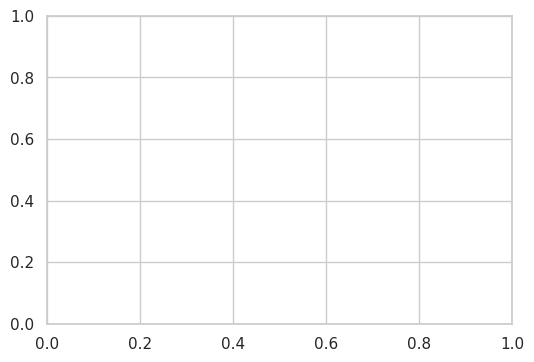

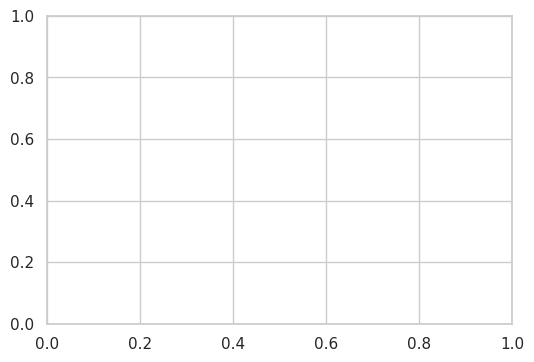

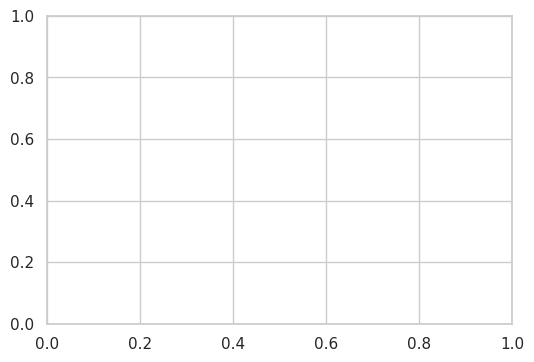

In [ ]:
# After training:
# - clf: CatBoostClassifier (Stage 1: probability of revenue > 0)
# - regr: CatBoostRegressor  (Stage 2: log1p(revenue) for positives)
# - X_train, X_val, y_train_reg, y_val_reg (original units)
# - cat_cols: your categorical feature names

_ = generate_two_stage_html_report(
    clf=clf,
    regr=regr,
    X_train=X_train,
    X_val=X_val,
    y_train_reg=y_train_reg,
    y_val_reg=y_val_reg,
    cat_cols=cat_cols,
    report_path="two_stage_model_report.html",
    title="Two-Stage Revenue Model — Validation Report",
    segment_series=full.loc[X_val.index, "customer_segment"] if "customer_segment" in full.columns else None,
    include_thresholded=True,
    threshold_grid=np.linspace(0.01, 0.80, 40),
    use_bias_correction=True,
    shap_sample_n=4000,
    pdp_features=None,  # auto-select top continuous features if None
    random_state=42
)
